# IPSA (CC01-1940): modelos de clasificación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/02_modelos_clasificacion.ipynb)

Este notebook entrena y evalúa los modelos de clasificación de la parte de `BD_IPSA_1940` del taller.
Continúa el análisis de `01_eda_ipsa.ipynb`, donde se definieron los predictores, el tratamiento de los
valores faltantes y las clases.

**Objetivo:** clasificar cada cosecha en un nivel bajo, medio o alto de TCH y de sacarosa, como dos
problemas independientes, con información disponible antes de la cosecha. Se comparan dos modelos
(regresión logística multinomial con regularización y KNN) y dos definiciones de clase (umbrales del
Ingenio y terciles).

**Entrada.** El archivo `datos/ipsa_limpio.parquet`, generado al final de `01_eda_ipsa.ipynb`. Contiene
los targets, la marca `excluir_tch`, los 13 predictores seleccionados y las clases definidas con los
umbrales del Ingenio. En Colab hay que ejecutar primero `01_eda_ipsa.ipynb` en la misma sesión, o subir
el archivo `ipsa_limpio.parquet` a la carpeta `datos/`.

**Criterios generales**

- La partición en entrenamiento (80 %) y prueba (20 %) debe reproducir la situación en la que se usaría
  el modelo: clasificar cosechas antes de que ocurran. La forma de agrupar las cosechas para lograrlo se
  define en la sección 11, y la validación cruzada usa la misma agrupación.
- Todos los estadísticos se calculan solo con el conjunto de entrenamiento. La imputación, el acotamiento
  y el escalado se ajustan dentro de un pipeline, de modo que se recalculan en cada pliegue de la
  validación cruzada. Los cortes de los terciles se calculan una vez, sobre el conjunto de entrenamiento.
- Los 4 registros marcados con `excluir_tch` se excluyen de la clasificación de TCH y se conservan en la
  de sacarosa.
- Las clases no están balanceadas con los umbrales del Ingenio, así que se reportan métricas por clase
  (precisión, sensibilidad y F1), el F1 macro, el índice kappa y el área bajo la curva ROC, además de la
  exactitud. La sensibilidad de la clase baja tiene especial importancia, porque corresponde a las
  suertes que el Ingenio necesita detectar.

**Flujo del notebook**

10. Carga del dataset procesado
11. Partición en entrenamiento y prueba
12. Clases por terciles
13. Pipeline de preprocesamiento
14. Regresión logística multinomial
15. KNN
16. Evaluación de variables candidatas (`anio`, armónicos del mes, `lluvia_sin_dato`, `edad²` y un
    conjunto reducido para KNN)
17. Evaluación en el conjunto de prueba
18. Interpretación y conclusiones

> **Datos:** `datos/ipsa_limpio.parquet` no está en el repositorio porque el enunciado prohíbe publicar
> los datos.

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.1


## 10. Carga del dataset procesado

Se carga el dataset generado por `01_eda_ipsa.ipynb` y se verifica que conserva las propiedades
establecidas en el EDA: número de registros y columnas, registros marcados con `excluir_tch`, clases
del Ingenio y valores faltantes en los predictores. Si alguna verificación falla, el archivo no
corresponde a la versión final del EDA y el notebook se detiene.

In [87]:
# 10. Carga del dataset procesado
RANDOM_STATE = 42  # mismo valor que en el análisis de regresión del histórico de suertes

df = pd.read_parquet("datos/ipsa_limpio.parquet")

# Predictores definidos en la sección 7 del EDA
predictores_num = ["edad", "cortes", "semsmad", "lluvias", "pct_diatrea", "dosismad", "anio"]
predictores_bin = ["lluvia_sin_dato"]
predictores_mes = ["mes_sin_12", "mes_cos_12", "mes_sin_6", "mes_cos_6"]
predictores_cat = ["grupo_tenencia"]
predictores = predictores_num + predictores_bin + predictores_mes + predictores_cat

# Verificaciones de lo establecido en el EDA
assert df.shape == (2187, 22), f"Dimensiones inesperadas: {df.shape}"
assert set(predictores) <= set(df.columns), "Faltan predictores en el archivo"
assert df["excluir_tch"].sum() == 4, "El número de registros con excluir_tch no es 4"
assert df.loc[df["excluir_tch"], "clase_tch_ingenio"].isna().all(), "Registros excluidos con clase de TCH"
assert df.loc[~df["excluir_tch"], "clase_tch_ingenio"].notna().all(), "Registros válidos sin clase de TCH"
assert df["clase_sac_ingenio"].notna().all(), "Registros sin clase de sacarosa"
assert df["clase_tch_ingenio"].cat.ordered, "Las clases perdieron su orden (bajo < medio < alto)"

nulos_esperados = {"lluvias": 685, "semsmad": 2, "dosismad": 2}
nulos = df[predictores].isna().sum()
assert nulos[nulos > 0].to_dict() == nulos_esperados, f"Faltantes inesperados: {nulos[nulos > 0].to_dict()}"

print("Registros:", len(df), "| Predictores:", len(predictores))
display(df.head())

Registros: 2187 | Predictores: 13


,FAZ,TAL,periodo,mes,TCH,sacarosa,excluir_tch,edad,cortes,semsmad,lluvias,pct_diatrea,dosismad,anio,lluvia_sin_dato,mes_sin_12,mes_cos_12,mes_sin_6,mes_cos_6,grupo_tenencia,clase_tch_ingenio,clase_sac_ingenio
0,81291,40,202012,12,112,14.0,False,12.3,4,8.3,137.0,6.2,0.8,2020,False,-2.449294e-16,1.000000e+00,-4.898587e-16,1.0,3,bajo,alto
1,81291,41,201903,3,157,13.0,False,11.2,2,6.3,NaN,3.5,0.8,2019,True,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
2,81291,41,202003,3,167,13.3,False,12.2,3,7.9,68.0,4.3,0.6,2020,False,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
3,81291,43,201903,3,156,13.4,False,13.1,1,6.6,NaN,3.5,0.8,2019,True,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
4,81291,43,202003,3,151,14.0,False,12.2,2,8.1,68.0,4.3,0.6,2020,False,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto


### Conclusión de la sección 10

El dataset tiene 2.187 registros y 22 columnas, y cumple todas las propiedades establecidas en el EDA:
13 predictores, 4 registros marcados con `excluir_tch` sin clase de TCH, clases de sacarosa completas con
el orden bajo < medio < alto, y faltantes solo en `lluvias` (685), `semsmad` (2) y `dosismad` (2).

## 11. Partición en entrenamiento y prueba

Los datos se dividen en entrenamiento (80 %) y prueba (20 %) antes de cualquier imputación, escalado o
cálculo de terciles. El conjunto de prueba no se vuelve a usar hasta la evaluación final (sección 17).

La partición debe reproducir la situación en la que se usaría el modelo: clasificar las cosechas de un
periodo antes de que ocurran, cuando ninguna cosecha de ese periodo tiene todavía su resultado. Por eso
se revisa primero cómo se distribuyen las cosechas de cada hacienda en el tiempo (11.1), y con ese
resultado se define la partición (11.2).

### 11.1 Cosechas simultáneas de una misma hacienda

Una hacienda puede cosechar varias de sus suertes en el mismo periodo (`periodo`, año y mes). Esas
cosechas comparten el año y el mes, y pueden tener valores parecidos de los demás predictores y
resultados parecidos, por compartir suelo, manejo y condiciones climáticas. Si una de ellas queda en
entrenamiento y otra en prueba, el modelo se evalúa con información de una cosecha simultánea, que no
estaría disponible al clasificar un periodo antes de que ocurra.

Para medir qué tan frecuente es esta situación, se calcula la proporción de cosechas que tienen al menos
otra suerte de su hacienda cosechada en el mismo periodo. Después se comparan todas las parejas de
cosechas de suertes distintas, separadas en tres tipos: de la misma hacienda y el mismo periodo, de otra
hacienda en el mismo periodo, y de periodos distintos. Para cada tipo se calcula el porcentaje de parejas
con la misma lluvia registrada, la diferencia mediana de edad y de número de cortes, y el porcentaje de
parejas con la misma clase de TCH y de sacarosa según los umbrales del Ingenio, que se compara con la
coincidencia esperada por azar.

In [88]:
# 11.1 Cosechas simultáneas de una misma hacienda
# Identificador de suerte (hacienda + suerte)
df["suerte"] = df["FAZ"].astype(str) + "_" + df["TAL"]

# Cosechas de cada hacienda en cada periodo
tam_grupo = df.groupby(["FAZ", "periodo"])["suerte"].transform("size")
print(f"Cosechas con al menos otra suerte de su hacienda en el mismo periodo: "
      f"{(tam_grupo > 1).sum()} de {len(df)} ({(tam_grupo > 1).mean():.1%})")
print(f"Mediana de suertes cosechadas por hacienda y periodo: "
      f"{df.groupby(['FAZ', 'periodo']).size().median():.0f}")

# Todas las parejas de cosechas de suertes distintas, clasificadas por hacienda y periodo
i, j = np.triu_indices(len(df), k=1)
a, b = df.iloc[i].reset_index(drop=True), df.iloc[j].reset_index(drop=True)
distinta_suerte = (a["suerte"] != b["suerte"]).to_numpy()
a, b = a[distinta_suerte].reset_index(drop=True), b[distinta_suerte].reset_index(drop=True)

tipo = pd.Series(np.select(
    [(a["FAZ"] == b["FAZ"]) & (a["periodo"] == b["periodo"]), a["periodo"] == b["periodo"]],
    ["Misma hacienda y mismo periodo", "Otra hacienda, mismo periodo"],
    default="Distinto periodo",
), name="Tipo de pareja")


def porcentaje_igual(col):
    """Porcentaje de parejas con el mismo valor, entre las que tienen el dato en ambas cosechas."""
    validas = a[col].notna() & b[col].notna()
    igual = (a[col].astype(object) == b[col].astype(object)).astype(float).where(validas)
    return igual.groupby(tipo).mean().mul(100)


parejas = pd.DataFrame({
    "Parejas": tipo.value_counts(),
    "% misma lluvia": porcentaje_igual("lluvias"),
    "Dif. mediana de edad (meses)": (a["edad"] - b["edad"]).abs().groupby(tipo).median(),
    "Dif. mediana de cortes": (a["cortes"] - b["cortes"]).abs().groupby(tipo).median(),
    "% misma clase TCH": porcentaje_igual("clase_tch_ingenio"),
    "% misma clase sacarosa": porcentaje_igual("clase_sac_ingenio"),
}).reindex(["Misma hacienda y mismo periodo", "Otra hacienda, mismo periodo", "Distinto periodo"])
display(parejas.round(1))

# Coincidencia esperada por azar: probabilidad de que dos cosechas al azar tengan la misma clase
azar = {col: (df[col].value_counts(normalize=True) ** 2).sum() * 100
        for col in ["clase_tch_ingenio", "clase_sac_ingenio"]}
print(f"Coincidencia de clase esperada por azar: TCH {azar['clase_tch_ingenio']:.1f} % | "
      f"sacarosa {azar['clase_sac_ingenio']:.1f} %")

Cosechas con al menos otra suerte de su hacienda en el mismo periodo: 1365 de 2187 (62.4%)
Mediana de suertes cosechadas por hacienda y periodo: 1


,Parejas,% misma lluvia,Dif. mediana de edad (meses),Dif. mediana de cortes,% misma clase TCH,% misma clase sacarosa
Tipo de pareja,,,,,,
Misma hacienda y mismo periodo,1655,34.5,0.2,0.0,58.3,56.0
"Otra hacienda, mismo periodo",53174,0.7,0.7,1.0,36.3,48.1
Distinto periodo,2333868,0.3,0.9,1.0,35.0,35.2


Coincidencia de clase esperada por azar: TCH 35.1 % | sacarosa 35.6 %


### Conclusión de 11.1

- El 62.4 % de las cosechas (1.365 de 2.187) tiene al menos otra suerte de su hacienda cosechada en el
  mismo periodo.

| Tipo de pareja | Parejas | Misma lluvia | Dif. mediana de edad | Dif. mediana de cortes | Misma clase TCH | Misma clase sacarosa |
|---|---|---|---|---|---|---|
| Misma hacienda y mismo periodo | 1.655 | 34.5 % | 0.2 meses | 0 | 58.3 % | 56.0 % |
| Otra hacienda, mismo periodo | 53.174 | 0.7 % | 0.7 meses | 1 | 36.3 % | 48.1 % |
| Distinto periodo | 2.333.868 | 0.3 % | 0.9 meses | 1 | 35.0 % | 35.2 % |

  La coincidencia de clase esperada por azar es 35.1 % en TCH y 35.6 % en sacarosa.

- Las cosechas simultáneas de una misma hacienda tienen predictores muy parecidos: su edad difiere en
  0.2 meses, tienen el mismo número de cortes y el 34.5 % registra exactamente la misma lluvia, frente a
  menos del 1 % en los demás tipos de pareja. Que la lluvia no coincida en la mayoría de ellas indica que
  `lluvias` no es un valor común de la hacienda en el mes, sino que se acumula en una ventana propia de
  cada suerte.
- En TCH, la clase coincide en el 58.3 % de las parejas de la misma hacienda y el mismo periodo, frente
  al 35.0–36.3 % de los demás tipos, igual al azar. El parecido en tonelaje es propio de cada hacienda.
- En sacarosa, la coincidencia sube tanto en la misma hacienda (56.0 %) como en otras haciendas del mismo
  periodo (48.1 %), frente al 35.2 % entre periodos distintos. La sacarosa depende de condiciones que
  comparten todas las haciendas en un mismo mes.
- Con una partición agrupada solo por suerte, la mayoría de las cosechas tendría en entrenamiento otra
  cosecha simultánea casi idéntica en sus predictores y con una clase parecida, cuyo resultado no se
  conocería al momento de clasificar. Agrupar por hacienda evitaría las parejas de la misma hacienda,
  pero no las de otras haciendas del mismo periodo, que se parecen en sacarosa. La partición se agrupa
  por periodo, de modo que todas las cosechas de un mismo mes y año queden en el mismo conjunto.

### 11.2 Partición agrupada por periodo

La partición cumple tres condiciones:

- **Agrupada por periodo.** Todas las cosechas de un mismo mes y año quedan en el mismo conjunto. Así, el
  desempeño en prueba corresponde a periodos que el modelo no vio en el entrenamiento, sin cosechas
  simultáneas en el otro conjunto. En el análisis de regresión del histórico de suertes se usó una
  partición aleatoria de registros, y se documentó como limitación que las cosechas de una misma suerte
  pueden quedar en ambos conjuntos.
- **Estratificada.** Conserva en ambos conjuntos, en lo posible, la proporción de cada combinación de
  clases de TCH y de sacarosa (umbrales del Ingenio). Los cuatro registros con `excluir_tch` tienen TCH
  menor que 60 t/ha, así que para la estratificación se agrupan con la clase baja de TCH.
- **Común a ambos targets.** Los dos problemas se evalúan sobre los mismos periodos de prueba.

Se usa `StratifiedGroupKFold` con 5 pliegues, y uno de ellos se toma como conjunto de prueba, lo que
equivale a una proporción cercana al 20 %. Como cada periodo agrupa muchas cosechas, el conjunto de
prueba queda formado por pocos periodos completos, y puede dejar sin representar algunos meses del año.
El mes de cosecha es uno de los predictores con fundamento agronómico más claro, así que el pliegue se
elige con una regla fija que solo considera la composición del conjunto de prueba: el de menor número de
meses con menos de 10 cosechas y, en caso de empate, el de menor diferencia en la proporción de clases
entre entrenamiento y prueba. La regla no usa el desempeño de ningún modelo.

Además del tamaño y del balance de clases, se revisa cómo se distribuyen los años y los meses de
cosecha en cada conjunto. Por último, se cuenta cuántas cosechas de prueba pertenecen a suertes que
también tienen cosechas en entrenamiento, en otros periodos. Esa situación es legítima: al clasificar una
cosecha futura, las cosechas anteriores de la misma suerte ya tienen su resultado.

In [89]:
# 11.2 Partición en entrenamiento y prueba: agrupada por periodo y estratificada
from sklearn.model_selection import StratifiedGroupKFold

# Estrato: combinación de las clases del Ingenio de ambos targets
# Los 4 registros con excluir_tch tienen TCH < 60, así que solo para estratificar se agrupan con "bajo"
estrato = (df["clase_tch_ingenio"].astype(str).where(~df["excluir_tch"], "bajo")
           + "|" + df["clase_sac_ingenio"].astype(str))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pliegues = list(sgkf.split(df, estrato, groups=df["periodo"]))


def diferencia_clases(tr, te):
    """Máxima diferencia, en puntos porcentuales, entre la proporción de una clase en train y en test."""
    return max((tr[col].value_counts(normalize=True) - te[col].value_counts(normalize=True)).abs().max()
               for col in ["clase_tch_ingenio", "clase_sac_ingenio"]) * 100


# Características de cada uno de los 5 pliegues candidatos a conjunto de prueba
candidatos = pd.DataFrame([{
    "% test": len(te) / len(df) * 100,
    "Periodos en test": df.iloc[te]["periodo"].nunique(),
    "Meses con menos de 10 cosechas en test": (df.iloc[te]["mes"].value_counts()
                                               .reindex(range(1, 13), fill_value=0) < 10).sum(),
    "Años en test": df.iloc[te]["anio"].nunique(),
    "Máx. diferencia de clase (pp)": diferencia_clases(df.iloc[tr], df.iloc[te]),
} for tr, te in pliegues]).rename_axis("Pliegue")
display(candidatos.round(1))

# Regla: menos meses mal representados en test; en empate, menor diferencia de clases
elegido = candidatos.sort_values(["Meses con menos de 10 cosechas en test",
                                  "Máx. diferencia de clase (pp)"]).index[0]
idx_train, idx_test = pliegues[elegido]
df_train, df_test = df.iloc[idx_train].copy(), df.iloc[idx_test].copy()
print(f"Pliegue elegido como conjunto de prueba: {elegido}")

# Ningún periodo puede estar en ambos conjuntos
assert set(df_train["periodo"]).isdisjoint(df_test["periodo"]), "Hay periodos en train y en test"

for nombre, d in [("Train", df_train), ("Test", df_test)]:
    print(f"{nombre}: {len(d)} registros ({len(d) / len(df):.1%}) | {d['periodo'].nunique()} periodos | "
          f"{d['suerte'].nunique()} suertes")
print("Registros con excluir_tch en train / test:",
      df_train["excluir_tch"].sum(), "/", df_test["excluir_tch"].sum())

# Proporción de cada clase en train y en test, por target
balance_split = pd.DataFrame({
    ("TCH", "train"): df_train["clase_tch_ingenio"].value_counts(normalize=True),
    ("TCH", "test"): df_test["clase_tch_ingenio"].value_counts(normalize=True),
    ("sacarosa", "train"): df_train["clase_sac_ingenio"].value_counts(normalize=True),
    ("sacarosa", "test"): df_test["clase_sac_ingenio"].value_counts(normalize=True),
}).reindex(["bajo", "medio", "alto"]).mul(100).round(1)
display(balance_split)

# Distribución de las cosechas por año y por mes en cada conjunto
display(pd.DataFrame({"Train": df_train["anio"].value_counts(), "Test": df_test["anio"].value_counts()})
        .sort_index().fillna(0).astype(int).rename_axis("Año").T)
display(pd.DataFrame({"Train": df_train["mes"].value_counts(), "Test": df_test["mes"].value_counts()})
        .sort_index().fillna(0).astype(int).rename_axis("Mes").T)

# Suertes con cosechas en ambos conjuntos (en periodos distintos)
suertes_comunes = set(df_train["suerte"]) & set(df_test["suerte"])
en_comun = df_test["suerte"].isin(suertes_comunes)
print(f"Cosechas de prueba cuya suerte tiene otra cosecha en entrenamiento: {en_comun.sum()} de "
      f"{len(df_test)} ({en_comun.mean():.1%})")

,% test,Periodos en test,Meses con menos de 10 cosechas en test,Años en test,Máx. diferencia de clase (pp)
Pliegue,,,,,
0,19.6,12,5,5,3.0
1,19.8,15,6,7,0.7
2,19.9,15,4,7,2.3
3,20.6,16,4,6,0.3
4,20.2,14,6,5,0.8


Pliegue elegido como conjunto de prueba: 3
Train: 1737 registros (79.4%) | 56 periodos | 1000 suertes
Test: 450 registros (20.6%) | 16 periodos | 401 suertes
Registros con excluir_tch en train / test: 4 / 0


TCH       sacarosa      
      train  test    train  test
bajo   22.6  22.7     21.5  21.6
medio  38.9  39.1     36.6  36.9
alto   38.5  38.2     41.9  41.6

Año,2014,2015,2016,2017,2018,2019,2020,2021
Train,1,28,89,190,244,522,577,86
Test,0,7,21,27,164,80,151,0


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Train,216,67,98,82,173,175,90,104,167,249,126,190
Test,15,3,87,98,1,44,36,45,54,5,62,0


Cosechas de prueba cuya suerte tiene otra cosecha en entrenamiento: 326 de 450 (72.4%)


### Conclusión de 11.2

| Pliegue | % test | Periodos en test | Meses con menos de 10 cosechas en test | Años en test | Máx. diferencia de clase (pp) |
|---|---|---|---|---|---|
| 0 | 19.6 | 12 | 5 | 5 | 3.0 |
| 1 | 19.8 | 15 | 6 | 7 | 0.7 |
| 2 | 19.9 | 15 | 4 | 7 | 2.3 |
| **3** | **20.6** | **16** | **4** | **6** | **0.3** |
| 4 | 20.2 | 14 | 6 | 5 | 0.8 |

- Se eligió el pliegue 3. Comparte con el pliegue 2 el menor número de meses mal representados (4), y
  tiene la menor diferencia en la proporción de clases entre entrenamiento y prueba (0.3 puntos
  porcentuales).

| | Registros | Periodos | Suertes |
|---|---|---|---|
| Entrenamiento | 1.737 (79.4 %) | 56 | 1.000 |
| Prueba | 450 (20.6 %) | 16 | 401 |

- Ningún periodo aparece en ambos conjuntos, así que el desempeño en prueba corresponde a periodos que el
  modelo no vio durante el entrenamiento, sin cosechas simultáneas en entrenamiento.
- La proporción de cada clase del Ingenio difiere como máximo 0.3 puntos porcentuales entre
  entrenamiento y prueba, en ambos targets:

| Clase | TCH train | TCH test | Sacarosa train | Sacarosa test |
|---|---|---|---|---|
| Bajo | 22.6 % | 22.7 % | 21.5 % | 21.6 % |
| Medio | 38.9 % | 39.1 % | 36.6 % | 36.9 % |
| Alto | 38.5 % | 38.2 % | 41.9 % | 41.6 % |

- El conjunto de prueba cubre las cosechas de 2015 a 2020. No incluye 2014 ni 2021, que tienen pocas
  cosechas en total (1 y 86).
- Ningún pliegue cubre bien los 12 meses, porque el conjunto de prueba está formado por solo 16
  periodos. En el elegido, febrero (3 cosechas), mayo (1), octubre (5) y diciembre (0) quedan con menos
  de 10 cosechas en prueba. El conjunto de entrenamiento sí tiene al menos 67 cosechas en cada mes, así
  que los modelos aprenden el efecto de todos los meses, pero la evaluación final no mide su desempeño
  en esos cuatro.
- El 72.4 % de las cosechas de prueba (326 de 450) pertenece a suertes que tienen cosechas en
  entrenamiento, en otros periodos. Esa información estaría disponible al clasificar una cosecha futura.
- Los cuatro registros con `excluir_tch` quedaron en el conjunto de entrenamiento. La clasificación de
  TCH usa 1.733 registros de entrenamiento y los 450 de prueba; la de sacarosa usa los 1.737 y los 450.

### Conclusión de la sección 11

La mayoría de las cosechas tiene otra suerte de su hacienda cosechada en el mismo periodo, con
predictores casi idénticos y una clase de TCH parecida. Además, la sacarosa de haciendas distintas se
parece dentro de un mismo periodo. Por eso la partición se agrupa por periodo: el conjunto de prueba
está formado por 16 meses completos (450 cosechas, 20.6 %), sin cosechas simultáneas en entrenamiento, y
conserva la proporción de clases con una diferencia máxima de 0.3 puntos porcentuales. La evaluación
final no cubre bien febrero, mayo, octubre y diciembre, que quedan con menos de 10 cosechas en prueba.
La validación cruzada de las secciones 14 y 15 usa la misma agrupación por periodo.

## 12. Clases por terciles

La segunda definición de clase divide cada target en tres grupos del mismo tamaño. Los cortes (percentiles
33 y 67) se calculan solo con el conjunto de entrenamiento y se aplican a ambos conjuntos, de modo que las
clases del conjunto de prueba se asignan con fronteras calculadas sin sus datos. En TCH se excluyen del
cálculo los registros con `excluir_tch`, que tampoco reciben clase.

Se comparan los cortes obtenidos con los terciles de referencia del EDA, calculados sobre el dataset
completo, y con los umbrales del Ingenio, y se verifica el balance de las clases en ambos conjuntos.

In [90]:
# 12. Clases por terciles, con cortes calculados solo en el conjunto de entrenamiento
orden_clases = pd.CategoricalDtype(["bajo", "medio", "alto"], ordered=True)

config_terciles = {
    "TCH": {"col_clase": "clase_tch_terciles", "validos": ~df_train["excluir_tch"]},
    "sacarosa": {"col_clase": "clase_sac_terciles", "validos": df_train["sacarosa"].notna()},
}

cortes_terciles = {}
for tgt, cfg in config_terciles.items():
    p33, p67 = df_train.loc[cfg["validos"], tgt].quantile([1 / 3, 2 / 3])
    cortes_terciles[tgt] = (p33, p67)
    # Mismo criterio que pd.qcut: cada intervalo incluye su límite superior
    for d in (df_train, df_test):
        d[cfg["col_clase"]] = pd.cut(d[tgt], bins=[-np.inf, p33, p67, np.inf],
                                     labels=orden_clases.categories).astype(orden_clases)

# Los registros con excluir_tch no tienen clase de TCH en ninguna definición
for d in (df_train, df_test):
    d.loc[d["excluir_tch"], "clase_tch_terciles"] = np.nan

# Cortes obtenidos frente a las referencias del EDA y a los umbrales del Ingenio
display(pd.DataFrame({
    "Terciles (train)": [f"{a:.2f} y {b:.2f}" for a, b in cortes_terciles.values()],
    "Terciles de referencia (EDA)": ["133.00 y 153.67", "12.40 y 13.10"],
    "Umbrales del Ingenio": ["125 y 150", "12.2 y 13.0"],
}, index=["TCH", "sacarosa"]))

# Balance de las clases por terciles en ambos conjuntos
balance_terciles = pd.DataFrame({
    ("TCH", "train"): df_train["clase_tch_terciles"].value_counts(normalize=True),
    ("TCH", "test"): df_test["clase_tch_terciles"].value_counts(normalize=True),
    ("sacarosa", "train"): df_train["clase_sac_terciles"].value_counts(normalize=True),
    ("sacarosa", "test"): df_test["clase_sac_terciles"].value_counts(normalize=True),
}).mul(100).round(1)
display(balance_terciles)

print("Registros sin clase de TCH por terciles (train / test):",
      df_train["clase_tch_terciles"].isna().sum(), "/", df_test["clase_tch_terciles"].isna().sum())

,Terciles (train),Terciles de referencia (EDA),Umbrales del Ingenio
TCH,133.00 y 153.00,133.00 y 153.67,125 y 150
sacarosa,12.40 y 13.10,12.40 y 13.10,12.2 y 13.0


TCH       sacarosa      
      train  test    train  test
bajo   34.7  32.9     34.9  34.4
medio  32.0  33.6     32.4  32.7
alto   33.3  33.6     32.7  32.9

Registros sin clase de TCH por terciles (train / test): 4 / 0


### Conclusión de la sección 12

| Target | Terciles (train) | Terciles de referencia (EDA) | Umbrales del Ingenio |
|---|---|---|---|
| TCH | 133 y 153 t/ha | 133 y 153.67 t/ha | 125 y 150 t/ha |
| Sacarosa | 12.4 % y 13.1 % | 12.4 % y 13.1 % | 12.2 % y 13.0 % |

- Los cortes calculados con el conjunto de entrenamiento coinciden con los del dataset completo, salvo una
  diferencia de 0.67 t/ha en el corte superior de TCH. Como TCH se registra en valores enteros, las clases
  resultantes son equivalentes.
- Una vez calculados, los cortes funcionan como umbrales fijos: cada registro de entrenamiento y de prueba
  se clasifica según su propio valor del target. Las clases del conjunto de prueba no dependen de sus
  propios percentiles, igual que las de una cosecha futura no podrían depender de la distribución de
  cosechas que aún no ocurren.
- Las clases por terciles quedan casi balanceadas en ambos conjuntos:

| Clase | TCH train | TCH test | Sacarosa train | Sacarosa test |
|---|---|---|---|---|
| Bajo | 34.7 % | 32.9 % | 34.9 % | 34.4 % |
| Medio | 32.0 % | 33.6 % | 32.4 % | 32.7 % |
| Alto | 33.3 % | 33.6 % | 32.7 % | 32.9 % |

  La partición no se estratificó por terciles, y aun así las proporciones en prueba difieren como máximo
  1.8 puntos porcentuales de las de entrenamiento, porque ambos conjuntos provienen de la misma población.
  Las desviaciones respecto a 33.3 % en entrenamiento se deben a valores repetidos del target, que deben
  quedar en la misma clase.
- Durante la validación cruzada, los cortes se mantienen fijos con los valores calculados sobre todo el
  conjunto de entrenamiento, incluidos los pliegues que actúan como validación. Es una aproximación con
  un efecto menor: no altera la evaluación final en el conjunto de prueba.
- Cada target queda con dos definiciones de clase: `clase_tch_ingenio` y `clase_tch_terciles`, y
  `clase_sac_ingenio` y `clase_sac_terciles`.

## 13. Pipeline de preprocesamiento

El preprocesamiento se empaqueta en un pipeline antes de probar cualquier modelo. Así, cada estadístico
se ajusta solo con los datos de entrenamiento de cada pliegue de la validación cruzada, y el conjunto de
prueba recibe exactamente las mismas transformaciones al final.

La sección tiene dos partes: el transformador para `lluvias`, que no existe en scikit-learn y se
construye aparte (13.1), y el pipeline completo con el resto de predictores (13.2).

### 13.1 Transformador para `lluvias`

En el EDA se decidió tratar `lluvias` en dos pasos:

- **Imputación por mes de cosecha.** Los faltantes se reemplazan con la mediana de `lluvias` de su mes,
  porque la lluvia tiene un patrón estacional. Si un mes no tiene datos observados en el ajuste, se usa
  la mediana general.
- **Acotamiento al percentil 99.** Los valores por encima del percentil 99 se reemplazan por ese valor,
  para que unos pocos registros extremos no dominen las distancias de KNN.

Las medianas y el tope se calculan solo con los valores observados del conjunto de ajuste. El
transformador recibe `lluvias` y `mes`, y devuelve solo `lluvias`: el mes se usa para elegir la mediana,
pero no entra al modelo por esta vía, porque ya está representado por sus armónicos.

Antes de incluirlo en el pipeline, se prueba por separado: se ajusta con el conjunto de entrenamiento y
se verifica que no deja faltantes, que ningún valor supera el tope y que los valores observados por
debajo del tope no cambian.

In [91]:
# 13.1 Transformador para lluvias: mediana por mes de cosecha y acotamiento al percentil 99
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class ImputadorLluvias(BaseEstimator, TransformerMixin):
    """Imputa lluvias con la mediana de su mes de cosecha y acota los valores al percentil indicado.

    Recibe dos columnas en este orden: lluvias y mes. Devuelve solo lluvias.
    Las medianas y el tope se calculan con los valores observados del conjunto de ajuste.
    """

    def __init__(self, percentil_tope=99):
        self.percentil_tope = percentil_tope

    def fit(self, X, y=None):
        lluvias, mes = self._separar(X)
        observado = ~np.isnan(lluvias)
        self.mediana_mes_ = pd.Series(lluvias[observado]).groupby(mes[observado]).median().to_dict()
        self.mediana_global_ = float(np.median(lluvias[observado]))
        self.tope_ = float(np.percentile(lluvias[observado], self.percentil_tope))
        self.n_features_in_ = 2
        return self

    def transform(self, X):
        check_is_fitted(self, "tope_")
        lluvias, mes = self._separar(X)
        # Mediana del mes; si el mes no tuvo datos en el ajuste, mediana general
        mediana = pd.Series(mes).map(self.mediana_mes_).fillna(self.mediana_global_).to_numpy()
        lluvias = np.where(np.isnan(lluvias), mediana, lluvias)
        return np.minimum(lluvias, self.tope_).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["lluvias"], dtype=object)

    @staticmethod
    def _separar(X):
        X = np.asarray(X, dtype=float)
        return X[:, 0], X[:, 1].astype(int)


# Prueba aislada: ajuste solo con el conjunto de entrenamiento
imputador = ImputadorLluvias().fit(df_train[["lluvias", "mes"]])
lluvias_train = imputador.transform(df_train[["lluvias", "mes"]]).ravel()
lluvias_test = imputador.transform(df_test[["lluvias", "mes"]]).ravel()

assert not np.isnan(lluvias_train).any() and not np.isnan(lluvias_test).any(), "Quedaron faltantes"
assert max(lluvias_train.max(), lluvias_test.max()) <= imputador.tope_, "Hay valores sobre el tope"
sin_cambio = (df_train["lluvias"] <= imputador.tope_).to_numpy()  # NaN da False
assert np.array_equal(lluvias_train[sin_cambio], df_train["lluvias"].to_numpy()[sin_cambio]), \
    "Cambiaron valores observados por debajo del tope"

print(f"Mediana general: {imputador.mediana_global_:.1f} | Tope (P{imputador.percentil_tope}): "
      f"{imputador.tope_:.1f}")

# Mediana usada para imputar en cada mes de cosecha
display(pd.DataFrame({
    "Registros (train)": df_train.groupby("mes").size(),
    "Con dato (train)": df_train.groupby("mes")["lluvias"].count(),
    "Mediana imputada": pd.Series(imputador.mediana_mes_).round(1),
}).rename_axis("mes"))

# Registros afectados en cada conjunto
display(pd.DataFrame({
    "Imputados": [df_train["lluvias"].isna().sum(), df_test["lluvias"].isna().sum()],
    "Acotados al tope": [(df_train["lluvias"] > imputador.tope_).sum(),
                         (df_test["lluvias"] > imputador.tope_).sum()],
}, index=["train", "test"]))

Mediana general: 132.5 | Tope (P99): 748.1


,Registros (train),Con dato (train),Mediana imputada
mes,,,
1,216,129,134.0
2,67,56,75.0
3,98,61,101.0
4,82,45,198.0
5,173,99,181.0
6,175,139,172.0
7,90,71,109.0
8,104,68,129.5
9,167,103,74.0


,Imputados,Acotados al tope
train,571,12
test,114,0


### Conclusión de 13.1

- El transformador cumple las tres verificaciones: no deja faltantes, ningún valor supera el tope y los
  valores observados por debajo del tope no cambian.
- Se imputan 571 registros de entrenamiento (32.9 %) y 114 de prueba (25.3 %), que suman los 685
  faltantes identificados en el EDA.
- Los 12 meses tienen datos observados en el conjunto de entrenamiento, con al menos 45 registros por
  mes (abril es el de menos), así que todas las imputaciones usan la mediana de su mes y ninguna la
  mediana general.
- Las medianas por mes van de 74 mm (septiembre) a 206 mm (diciembre), frente a una mediana general de
  132.5 mm. Imputar con la mediana general habría asignado el mismo valor a cosechas de meses con lluvias
  muy distintas.
- El tope es 748.1 mm, más de cinco veces la mediana. Se acotan 12 registros de entrenamiento y ninguno
  de prueba, así que el acotamiento solo actúa sobre los valores más extremos.
- Los valores imputados son una aproximación, no una medición. La bandera `lluvia_sin_dato` permite al
  modelo distinguir los registros con lluvia medida de los imputados.

### 13.2 Pipeline completo

El pipeline combina el transformador de `lluvias` con el tratamiento del resto de predictores:

| Grupo | Columnas | Transformación |
|---|---|---|
| Lluvias | `lluvias` (con `mes` como apoyo) | Mediana por mes y acotamiento al percentil 99 (13.1) |
| Numéricas | `edad`, `cortes`, `semsmad`, `pct_diatrea`, `dosismad`, `anio` | Imputación con la mediana |
| Directas | `lluvia_sin_dato` y los cuatro armónicos del mes | Ninguna antes del escalado |
| Categórica | `grupo_tenencia` | Indicadoras, con el código 1 como referencia |

Después, todas las columnas se estandarizan. KNN mide distancias, así que sin escalado dominarían las
variables con valores más grandes, como `lluvias` o `anio`. En la regresión logística, el escalado hace que
la regularización penalice por igual a todos los coeficientes y que sus magnitudes sean comparables.

Las variables binarias y las indicadoras también se escalan, para que tengan el mismo peso que las
continuas en las distancias de KNN y en la penalización de la logística. Solo se imputa con la mediana
en `semsmad` y `dosismad`, que tienen 2 faltantes cada una. En el resto de columnas numéricas el
imputador no cambia ningún valor.

El pipeline se construye con una función, porque en la sección 16 se construye con otros conjuntos de
predictores. Se ajusta con el conjunto de entrenamiento y se verifica que no quedan faltantes, que `mes`
no llega al modelo y que las columnas de entrenamiento tienen media 0 y desviación 1. Por último, se
calcula el VIF sobre la matriz de diseño de entrenamiento, que ahora incluye `lluvias` imputada, la
bandera, los armónicos y las indicadoras.

In [92]:
# 13.2 Pipeline de preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# mes solo entra para elegir la mediana de lluvias; el ColumnTransformer no lo devuelve
columnas_entrada = predictores + ["mes"]
predictores_num_mediana = [c for c in predictores_num if c != "lluvias"]


def crear_preprocesador(num=predictores_num_mediana, directas=predictores_bin + predictores_mes,
                        cat=predictores_cat):
    """Imputación, codificación y escalado. Todo se ajusta con los datos que recibe fit()."""
    columnas = ColumnTransformer(
        [
            ("lluvias", ImputadorLluvias(), ["lluvias", "mes"]),
            ("num", SimpleImputer(strategy="median"), num),
            ("directas", "passthrough", directas),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline([("columnas", columnas), ("escalado", StandardScaler())]).set_output(transform="pandas")


preprocesador = crear_preprocesador()
X_train_prep = preprocesador.fit_transform(df_train[columnas_entrada])
X_test_prep = preprocesador.transform(df_test[columnas_entrada])

assert X_train_prep.notna().all().all() and X_test_prep.notna().all().all(), "Quedaron faltantes"
assert "mes" not in X_train_prep.columns, "mes no debe llegar al modelo"
assert np.allclose(X_train_prep.mean(), 0) and np.allclose(X_train_prep.std(ddof=0), 1), \
    "El escalado no se ajustó con train"

print("Matriz de diseño (train):", X_train_prep.shape, "| (test):", X_test_prep.shape)

# En test, media y desviación cercanas a 0 y 1 pero no exactas, porque el escalado viene de train
display(pd.DataFrame({
    "Media (test)": X_test_prep.mean(),
    "Desv. estándar (test)": X_test_prep.std(ddof=0),
}).round(2).T)

Matriz de diseño (train): (1737, 14) | (test): (450, 14)


,lluvias,edad,cortes,semsmad,pct_diatrea,dosismad,anio,lluvia_sin_dato,mes_sin_12,mes_cos_12,mes_sin_6,mes_cos_6,grupo_tenencia_2,grupo_tenencia_3
Media (test),-0.12,-0.13,-0.04,-0.12,0.05,0.24,-0.15,-0.16,0.26,-0.35,-0.08,-0.48,0.08,-0.06
Desv. estándar (test),0.84,0.84,0.97,0.84,1.11,1.06,0.90,0.93,1.18,0.80,0.95,0.98,1.03,1.01


In [93]:
# 13.2 VIF sobre la matriz de diseño de entrenamiento
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_prep)
vif_diseno = pd.Series(
    [variance_inflation_factor(X_vif.to_numpy(), i) for i in range(1, X_vif.shape[1])],
    index=X_train_prep.columns, name="VIF",
).sort_values(ascending=False).round(2)
display(vif_diseno.to_frame())

,VIF
grupo_tenencia_3,3.36
edad,2.57
grupo_tenencia_2,2.49
semsmad,2.23
lluvias,2.00
lluvia_sin_dato,1.58
anio,1.57
dosismad,1.50
cortes,1.26
mes_cos_6,1.22


### Conclusión de 13.2

- La matriz de diseño tiene 14 columnas: 7 numéricas, la bandera de lluvia, los 4 armónicos del mes y 2
  indicadoras de `grupo_tenencia`. Tiene 1.737 filas en entrenamiento y 450 en prueba, sin faltantes.
- En prueba, las medias están entre −0.48 y 0.26 y las desviaciones entre 0.80 y 1.18. No son 0 y 1
  porque el escalado se ajustó con el conjunto de entrenamiento. Las mayores diferencias están en los
  armónicos del mes (`mes_cos_6` −0.48, `mes_cos_12` −0.35 y `mes_sin_12` 0.26): el conjunto de prueba
  está formado por 16 periodos y tiene una distribución de meses de cosecha distinta, con cuatro meses
  casi ausentes. También se desplazan `dosismad` (0.24) y `anio` (−0.15), este último porque el conjunto
  de prueba no incluye cosechas de 2021.
- Todos los VIF están por debajo de 5:

| Predictor | VIF |
|---|---|
| `grupo_tenencia_3` | 3.36 |
| `edad` | 2.57 |
| `grupo_tenencia_2` | 2.49 |
| `semsmad` | 2.23 |
| `lluvias` | 2.00 |
| `lluvia_sin_dato` | 1.58 |
| `anio` | 1.57 |
| `dosismad` | 1.50 |
| `cortes` | 1.26 |
| Armónicos del mes | 1.10 a 1.22 |
| `pct_diatrea` | 1.06 |

- Los VIF más altos corresponden a las indicadoras de `grupo_tenencia`. Con el código 1 como referencia,
  que solo tiene el 12.5 % de los registros, casi toda cosecha que no es del código 2 es del código 3, así
  que las dos indicadoras están fuertemente relacionadas entre sí. Es una consecuencia de la codificación y
  no de un solapamiento con otros predictores.
- `lluvias` tiene un VIF de 2.00. En el 32.9 % de los registros de entrenamiento su valor es la mediana de
  su mes, así que queda relacionada con los armónicos y con la bandera, pero no al punto de afectar la
  interpretación de los coeficientes.

### Conclusión de la sección 13

El preprocesamiento queda empaquetado en un pipeline que imputa `lluvias` por mes y la acota al
percentil 99, imputa con la mediana `semsmad` y `dosismad`, codifica `grupo_tenencia` y estandariza todas
las columnas. Todos sus estadísticos se ajustan con los datos que recibe en el entrenamiento, de modo que
en la validación cruzada se recalculan en cada pliegue. Los predictores no presentan multicolinealidad
relevante, así que los coeficientes de la regresión logística se pueden interpretar individualmente.

## 14. Regresión logística multinomial

La regresión logística multinomial estima, para cada registro, la probabilidad de pertenecer a cada una
de las tres clases, y asigna la más probable. Es el modelo base del enunciado: sus coeficientes indican
qué predictores empujan una cosecha hacia la clase baja o hacia la alta. Con regularización L1, algunos
coeficientes se anulan, lo que sirve como selección de variables.

El modelo se ajusta en cuatro casos: dos targets (TCH y sacarosa) por dos definiciones de clase (umbrales
del Ingenio y terciles). La sección tiene tres partes: el esquema de validación cruzada y los modelos de
referencia (14.1), la búsqueda de hiperparámetros (14.2) y el análisis de los coeficientes (14.3).

### 14.1 Esquema de validación cruzada y modelos de referencia

Los hiperparámetros se eligen con validación cruzada de 5 pliegues sobre el conjunto de entrenamiento.
Los pliegues se construyen igual que la partición de la sección 11: agrupados por suerte, para que el
desempeño en validación corresponda a suertes no vistas, y estratificados por la clase de cada caso. El
pipeline de la sección 13 se ajusta de nuevo en cada pliegue.

En cada pliegue se calculan nueve métricas. Las siete primeras evalúan la clase asignada, que es la de
mayor probabilidad:

- **Exactitud:** proporción de registros bien clasificados.
- **Precisión y sensibilidad macro:** promedio simple, sobre las tres clases, de la proporción de
  predicciones correctas de cada clase (precisión) y de la proporción de registros de cada clase que el
  modelo identifica (sensibilidad).
- **F1 macro:** promedio simple del F1 de las tres clases. Da el mismo peso a cada clase aunque tengan
  tamaños distintos, así que es la métrica principal para elegir hiperparámetros.
- **Precisión y sensibilidad de la clase baja:** las cosechas de desempeño bajo son las que el Ingenio
  necesita identificar para intervenir. La sensibilidad mide qué proporción de ellas detecta el modelo,
  y la precisión, qué proporción de las cosechas clasificadas como bajas lo son realmente. Ambas se
  reportan juntas porque una puede aumentar a costa de la otra: detectar más cosechas bajas suele
  implicar más falsas alarmas.
- **Kappa de Cohen:** acuerdo entre las clases predichas y las reales, descontando el acuerdo esperado
  por azar. Vale 0 para un clasificador aleatorio y 1 para uno perfecto.

Las dos últimas evalúan las probabilidades que el modelo asigna, sin depender del umbral de decisión:

- **AUC macro:** área bajo la curva ROC de cada clase frente a las otras dos, promediada sobre las tres
  clases. Es la probabilidad de que una cosecha de una clase reciba más probabilidad de pertenecer a
  ella que una cosecha de otra clase. Vale 0.5 para un modelo sin información y 1 para uno que ordena
  las cosechas perfectamente.
- **AUC de la clase baja:** la misma medida para la clase baja frente al resto. Indica si el modelo
  ordena bien las cosechas según su riesgo de ser bajas. Si lo hace, el Ingenio podría fijar un umbral
  de alerta distinto al de la clase más probable, según cuántas falsas alarmas esté dispuesto a aceptar.

Para saber si un modelo aprende algo, se comparan sus métricas con dos referencias que no usan los
predictores: un clasificador que siempre predice la clase más frecuente y uno que asigna clases al azar
con las proporciones de entrenamiento.

In [94]:
# 14.1 Esquema de validación cruzada y modelos de referencia
from sklearn.dummy import DummyClassifier
from sklearn.metrics import cohen_kappa_score, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_validate

# Los cuatro problemas de clasificación: dos targets por dos definiciones de clase
casos = {
    ("TCH", "Ingenio"): "clase_tch_ingenio",
    ("TCH", "terciles"): "clase_tch_terciles",
    ("sacarosa", "Ingenio"): "clase_sac_ingenio",
    ("sacarosa", "terciles"): "clase_sac_terciles",
}


def datos_caso(col_clase, datos):
    """X, y y grupos de un caso. Los registros sin clase (excluir_tch en TCH) quedan fuera."""
    d = datos[datos[col_clase].notna()]
    return d[columnas_entrada], d[col_clase].astype(str), d["suerte"]


# Validación cruzada dentro de train: 5 pliegues, agrupados por suerte y estratificados por la clase
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def auc_bajo(estimador, X, y):
    """AUC de la clase baja frente al resto, con la probabilidad que el modelo asigna a "bajo"."""
    proba_bajo = estimador.predict_proba(X)[:, list(estimador.classes_).index("bajo")]
    return roc_auc_score(y == "bajo", proba_bajo)


metricas = {
    "exactitud": "accuracy",
    "prec_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "sens_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "prec_bajo": make_scorer(precision_score, labels=["bajo"], average="macro", zero_division=0),
    "sens_bajo": make_scorer(recall_score, labels=["bajo"], average="macro"),
    "kappa": make_scorer(cohen_kappa_score),
    "auc_macro": "roc_auc_ovr",
    "auc_bajo": auc_bajo,
}


def evaluar_cv(modelo, col_clase):
    """Media y desviación estándar de cada métrica en los 5 pliegues."""
    X, y, grupos = datos_caso(col_clase, df_train)
    res = cross_validate(modelo, X, y, groups=grupos, cv=cv, scoring=metricas)
    return {f"{m} {e}": f(res[f"test_{m}"])
            for m in metricas for e, f in (("media", np.mean), ("desv", np.std))}


referencias = {
    "Clase más frecuente": DummyClassifier(strategy="most_frequent"),
    "Azar estratificado": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}

tabla_ref = pd.DataFrame({
    (tgt, defin, nombre): evaluar_cv(Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]), col)
    for (tgt, defin), col in casos.items()
    for nombre, modelo in referencias.items()
}).T
tabla_ref.index.names = ["Target", "Clases", "Referencia"]
display(tabla_ref[[c for c in tabla_ref.columns if c.endswith("media")]].round(3))

exactitud media  prec_macro media  \
Target   Clases   Referencia                                               
TCH      Ingenio  Clase más frecuente            0.389             0.130   
                  Azar estratificado             0.367             0.341   
         terciles Clase más frecuente            0.347             0.116   
                  Azar estratificado             0.338             0.337   
sacarosa Ingenio  Clase más frecuente            0.419             0.140   
                  Azar estratificado             0.362             0.339   
         terciles Clase más frecuente            0.349             0.116   
                  Azar estratificado             0.310             0.309   

                                       sens_macro media  f1_macro media  \
Target   Clases   Referencia                                              
TCH      Ingenio  Clase más frecuente             0.333           0.187   
                  Azar estratificado              0.341           0.338   
         terciles Clase más frecuente             0.333           0.172   
                  Azar estratificado              0.337           0.337   
sacarosa Ingenio  Clase más frecuente             0.333           0.197   
                  Azar estratificado              0.334           0.334   
         terciles Clase más frecuente             0.333           0.172   
                  Azar estratificado              0.309           0.308   

                                       prec_bajo media  sens_bajo media  \
Target   Clases   Referencia                                              
TCH      Ingenio  Clase más frecuente            0.000            0.000   
                  Azar estratificado             0.234            0.176   
         terciles Clase más frecuente            0.347            1.000   
                  Azar estratificado             0.350            0.352   
sacarosa Ingenio  Clase más frecuente            0.000            0.000   
                  Azar estratificado             0.261            0.193   
         terciles Clase más frecuente            0.349            1.000   
                  Azar estratificado             0.346            0.338   

                                       kappa media  auc_macro media  \
Target   Clases   Referencia                                          
TCH      Ingenio  Clase más frecuente        0.000            0.500   
                  Azar estratificado         0.012            0.506   
         terciles Clase más frecuente        0.000            0.500   
                  Azar estratificado         0.006            0.503   
sacarosa Ingenio  Clase más frecuente        0.000            0.500   
                  Azar estratificado        -0.008            0.499   
         terciles Clase más frecuente        0.000            0.500   
                  Azar estratificado        -0.036            0.482   

                                       auc_bajo media  
Target   Clases   Referencia                           
TCH      Ingenio  Clase más frecuente           0.500  
                  Azar estratificado            0.504  
         terciles Clase más frecuente           0.500  
                  Azar estratificado            0.502  
sacarosa Ingenio  Clase más frecuente           0.500  
                  Azar estratificado            0.521  
         terciles Clase más frecuente           0.500  
                  Azar estratificado            0.498

### Conclusión de 14.1

La tabla resume la media de las métricas en los 5 pliegues para los dos clasificadores de referencia en
cada caso. El de la clase más frecuente predice siempre la clase con más registros de entrenamiento: la
media en TCH y la alta en sacarosa con los umbrales del Ingenio, y la baja en ambos targets con terciles.
El de azar estratificado asigna clases al azar, con las proporciones de entrenamiento.

| Target | Clases | Clasificador de referencia | Exactitud | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Clase más frecuente | 0.390 | 0.187 | 0.000 | 0.000 | 0.000 | 0.500 | 0.500 |
| TCH | Ingenio | Azar estratificado | 0.366 | 0.341 | 0.253 | 0.193 | 0.010 | 0.506 | 0.514 |
| TCH | Terciles | Clase más frecuente | 0.344 | 0.171 | 0.344 | 1.000 | 0.000 | 0.500 | 0.500 |
| TCH | Terciles | Azar estratificado | 0.335 | 0.335 | 0.338 | 0.334 | 0.002 | 0.501 | 0.495 |
| Sacarosa | Ingenio | Clase más frecuente | 0.417 | 0.196 | 0.000 | 0.000 | 0.000 | 0.500 | 0.500 |
| Sacarosa | Ingenio | Azar estratificado | 0.366 | 0.325 | 0.185 | 0.135 | −0.002 | 0.497 | 0.486 |
| Sacarosa | Terciles | Clase más frecuente | 0.347 | 0.172 | 0.347 | 1.000 | 0.000 | 0.500 | 0.500 |
| Sacarosa | Terciles | Azar estratificado | 0.343 | 0.342 | 0.376 | 0.369 | 0.014 | 0.507 | 0.522 |

- Sin usar los predictores, el F1 macro llega a lo sumo a 0.325–0.342 (azar estratificado), el kappa es
  prácticamente 0 y el AUC queda entre 0.486 y 0.522 en los cuatro casos. Estos valores son el piso que
  deben superar la regresión logística y KNN.
- La exactitud no sirve como criterio de elección. El clasificador de la clase más frecuente alcanza
  0.390 en TCH y 0.417 en sacarosa con los umbrales del Ingenio, por encima del azar estratificado, aunque
  no distingue ninguna cosecha. Su F1 macro, en cambio, es el más bajo (0.171 a 0.196), porque obtiene F1
  nulo en dos de las tres clases.
- La sensibilidad de la clase baja tampoco sirve sola. Con terciles, la clase baja es la más frecuente
  en entrenamiento (34.4 % en TCH y 34.7 % en sacarosa), así que el clasificador de la clase más frecuente
  predice "bajo" para todas las cosechas y alcanza una sensibilidad de 1.000, con una precisión igual a la
  proporción de la clase (0.344 y 0.347). Por eso la sensibilidad de la clase baja se interpreta siempre
  junto con su precisión y con el F1 macro.
- El AUC no se deja engañar por ese caso: el mismo clasificador obtiene 0.500, porque asigna la misma
  probabilidad a todas las cosechas y no las ordena según su riesgo de ser bajas.
- Con el azar estratificado, la precisión y la sensibilidad de la clase baja quedan cerca de la
  proporción de esa clase, con variaciones entre pliegues. Un modelo que detecte cosechas bajas por
  encima de esos valores está usando información de los predictores.

### 14.2 Búsqueda de hiperparámetros

Para cada caso se buscan tres hiperparámetros con validación cruzada:

- **`C`:** inverso de la fuerza de regularización. Valores pequeños penalizan más los coeficientes y
  producen modelos más simples. Se prueban 11 valores entre 0.001 y 100, en escala logarítmica.
- **Tipo de regularización:** L2 (`l1_ratio = 0`), que reduce todos los coeficientes sin anularlos, o L1
  (`l1_ratio = 1`), que anula los de los predictores menos útiles.
- **Ponderación de clases:** sin ponderar, o balanceada (`class_weight = "balanced"`), que da más peso a los
  errores en las clases pequeñas. Con los umbrales del Ingenio la clase baja tiene cerca del 22 % de los
  registros, así que la ponderación puede mejorar su detección.

Para cada combinación se corre la validación cruzada completa de 14.1, y se elige la de mayor F1 macro
promedio. El F1 macro no supone ningún costo relativo entre los errores: da el mismo peso a las tres
clases. Los costos de no detectar una cosecha baja y de una falsa alarma no se conocen, así que ese
intercambio no se fija al elegir el modelo. Se analiza en la sección 17, variando el umbral de
probabilidad a partir del cual una cosecha se clasifica como baja. El AUC se reporta como complemento,
pero no interviene en la elección.

Las métricas de la combinación elegida son su media y su desviación estándar en los 5 pliegues. La
desviación indica qué tan estable es el modelo entre grupos de suertes distintos. Estas métricas son
algo optimistas, porque la combinación se eligió por su desempeño en esos mismos pliegues. La estimación
sin ese sesgo es la del conjunto de prueba (sección 17). Al final, la combinación elegida se reentrena
con todo el conjunto de entrenamiento.

Además de la tabla con la combinación elegida, se grafica el F1 macro de validación cruzada frente a `C`
para cada combinación de regularización y ponderación. La gráfica muestra si el desempeño es estable en
un rango amplio de `C`, o si depende de un valor preciso, y cuánto cambia entre L1 y L2 y con la
ponderación de clases. Por último, se compara la mejor combinación con L1 y la mejor con L2 en cada caso,
para saber si el tipo de regularización cambia el desempeño.

In [95]:
# 14.2 Búsqueda de hiperparámetros de la regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

grilla_log = {
    "modelo__C": np.logspace(-3, 2, 11),
    "modelo__l1_ratio": [0.0, 1.0],  # 0 = L2, 1 = L1
    "modelo__class_weight": [None, "balanced"],
}


def buscar(modelo, grilla, col_clase):
    """GridSearchCV con el pipeline completo, los pliegues agrupados y todas las métricas de 14.1.

    Elige la combinación de mayor F1 macro y la reentrena con todo el conjunto de entrenamiento.
    """
    X, y, grupos = datos_caso(col_clase, df_train)
    busqueda = GridSearchCV(
        Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]),
        grilla, scoring=metricas, refit="f1_macro", cv=cv, n_jobs=-1,
    )
    return busqueda.fit(X, y, groups=grupos)


def resumen_busqueda(busqueda):
    """Hiperparámetros elegidos y media ± desviación de cada métrica en los 5 pliegues."""
    fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
    res = {p.replace("modelo__", ""): fila[f"param_{p}"] for p in busqueda.param_grid}
    for m in metricas:
        res[m] = f"{fila[f'mean_test_{m}']:.3f} ± {fila[f'std_test_{m}']:.3f}"
    return res


modelo_log = LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE)
busquedas_log = {caso: buscar(modelo_log, grilla_log, col) for caso, col in casos.items()}

tabla_log = pd.DataFrame({caso: resumen_busqueda(b) for caso, b in busquedas_log.items()}).T
tabla_log.index.names = ["Target", "Clases"]
display(tabla_log)

C l1_ratio class_weight      exactitud  \
Target   Clases                                                    
TCH      Ingenio        1.0      0.0     balanced  0.449 ± 0.022   
         terciles  0.316228      1.0     balanced  0.486 ± 0.021   
sacarosa Ingenio   0.316228      1.0     balanced  0.509 ± 0.029   
         terciles     0.001      0.0     balanced  0.514 ± 0.023   

                      prec_macro     sens_macro       f1_macro      prec_bajo  \
Target   Clases                                                                 
TCH      Ingenio   0.450 ± 0.027  0.457 ± 0.020  0.439 ± 0.023  0.319 ± 0.027   
         terciles  0.481 ± 0.022  0.484 ± 0.021  0.479 ± 0.020  0.491 ± 0.049   
sacarosa Ingenio   0.487 ± 0.035  0.518 ± 0.033  0.486 ± 0.033  0.411 ± 0.033   
         terciles  0.498 ± 0.028  0.510 ± 0.022  0.497 ± 0.021  0.549 ± 0.032   

                       sens_bajo          kappa      auc_macro       auc_bajo  
Target   Clases                                                                
TCH      Ingenio   0.503 ± 0.035  0.180 ± 0.031  0.630 ± 0.016  0.642 ± 0.014  
         terciles  0.498 ± 0.050  0.227 ± 0.032  0.648 ± 0.017  0.655 ± 0.029  
sacarosa Ingenio   0.631 ± 0.058  0.256 ± 0.046  0.694 ± 0.031  0.752 ± 0.044  
         terciles  0.634 ± 0.046  0.268 ± 0.034  0.676 ± 0.015  0.736 ± 0.021

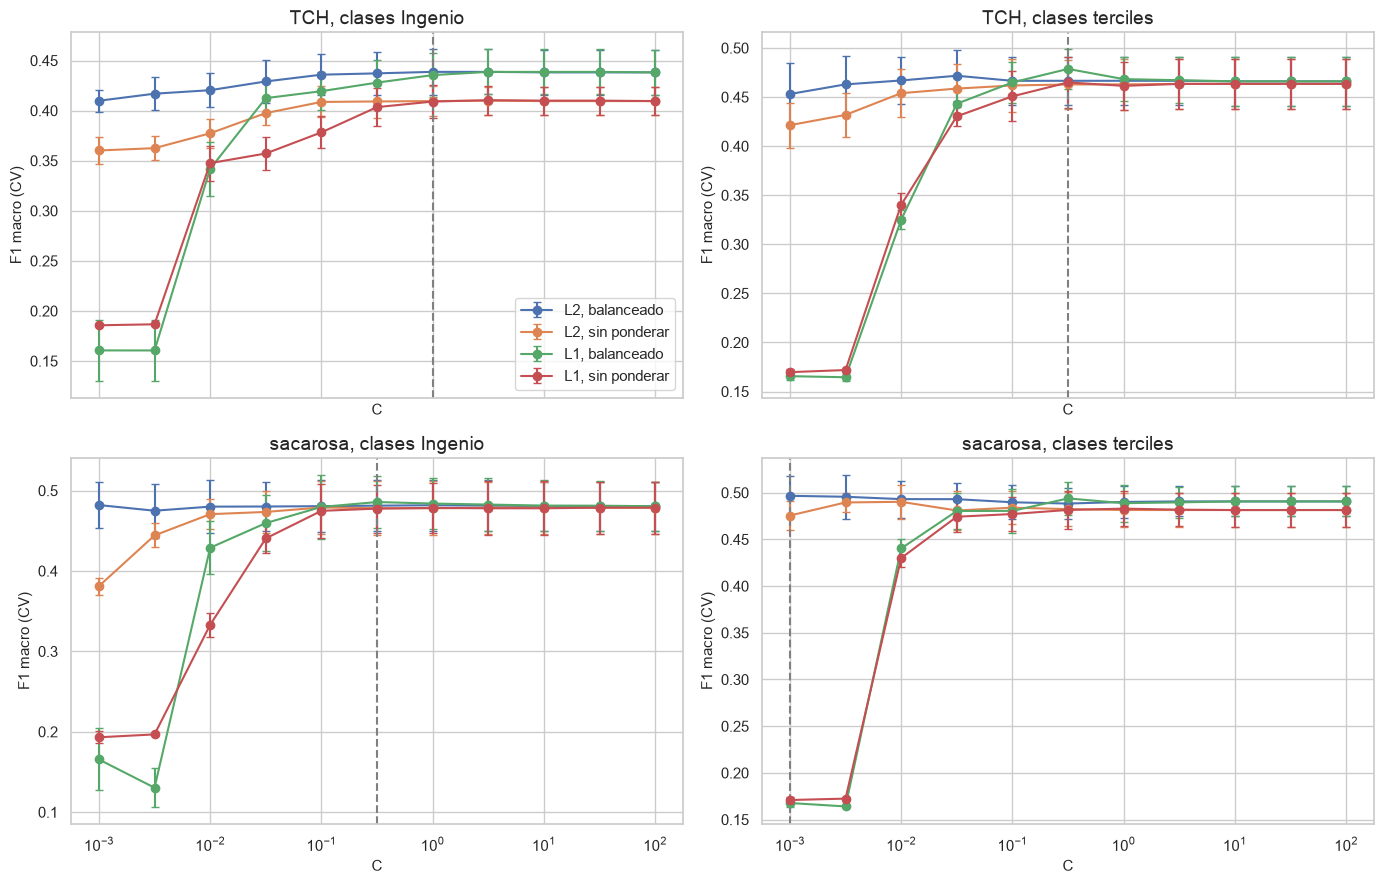

In [96]:
# 14.2 F1 macro de validación cruzada frente a C, por regularización y ponderación de clases
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (caso, busqueda) in zip(axes.ravel(), busquedas_log.items()):
    res = pd.DataFrame(busqueda.cv_results_)
    for (l1, cw), grupo in res.groupby(["param_modelo__l1_ratio", "param_modelo__class_weight"],
                                       dropna=False):
        etiqueta = f"{'L1' if l1 == 1 else 'L2'}, {'balanceado' if cw == 'balanced' else 'sin ponderar'}"
        ax.errorbar(grupo["param_modelo__C"].astype(float), grupo["mean_test_f1_macro"],
                    yerr=grupo["std_test_f1_macro"], marker="o", capsize=3, label=etiqueta)
    elegido = busqueda.cv_results_["param_modelo__C"][busqueda.best_index_]
    ax.axvline(float(elegido), color="gray", linestyle="--")
    ax.set(xscale="log", title=f"{caso[0]}, clases {caso[1]}", xlabel="C", ylabel="F1 macro (CV)")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [97]:
# 14.2 Mejor combinación con L1 y con L2 en cada caso
metricas_comparacion = ["f1_macro", "prec_bajo", "sens_bajo", "kappa", "auc_macro", "auc_bajo"]

filas = {}
for caso, busqueda in busquedas_log.items():
    res = pd.DataFrame(busqueda.cv_results_)
    for l1, grupo in res.groupby("param_modelo__l1_ratio"):
        mejor = grupo.loc[grupo["mean_test_f1_macro"].idxmax()]
        filas[(*caso, "L1" if l1 == 1 else "L2")] = {
            "C": mejor["param_modelo__C"],
            "class_weight": mejor["param_modelo__class_weight"],
            **{m: f"{mejor[f'mean_test_{m}']:.3f} ± {mejor[f'std_test_{m}']:.3f}"
               for m in metricas_comparacion},
        }

tabla_l1_l2 = pd.DataFrame(filas).T
tabla_l1_l2.index.names = ["Target", "Clases", "Regularización"]
display(tabla_l1_l2)

C class_weight       f1_macro  \
Target   Clases   Regularización                                         
TCH      Ingenio  L2                   1.0     balanced  0.439 ± 0.023   
                  L1              3.162278     balanced  0.439 ± 0.022   
         terciles L2              0.031623     balanced  0.472 ± 0.026   
                  L1              0.316228     balanced  0.479 ± 0.020   
sacarosa Ingenio  L2                 0.001     balanced  0.482 ± 0.028   
                  L1              0.316228     balanced  0.486 ± 0.033   
         terciles L2                 0.001     balanced  0.497 ± 0.021   
                  L1              0.316228     balanced  0.494 ± 0.018   

                                      prec_bajo      sens_bajo          kappa  \
Target   Clases   Regularización                                                
TCH      Ingenio  L2              0.319 ± 0.027  0.503 ± 0.035  0.180 ± 0.031   
                  L1              0.319 ± 0.026  0.500 ± 0.030  0.179 ± 0.031   
         terciles L2              0.481 ± 0.054  0.485 ± 0.054  0.216 ± 0.041   
                  L1              0.491 ± 0.049  0.498 ± 0.050  0.227 ± 0.032   
sacarosa Ingenio  L2              0.385 ± 0.036  0.631 ± 0.068  0.256 ± 0.039   
                  L1              0.411 ± 0.033  0.631 ± 0.058  0.256 ± 0.046   
         terciles L2              0.549 ± 0.032  0.634 ± 0.046  0.268 ± 0.034   
                  L1              0.557 ± 0.034  0.615 ± 0.043  0.269 ± 0.029   

                                      auc_macro       auc_bajo  
Target   Clases   Regularización                                
TCH      Ingenio  L2              0.630 ± 0.016  0.642 ± 0.014  
                  L1              0.630 ± 0.017  0.642 ± 0.014  
         terciles L2              0.648 ± 0.016  0.653 ± 0.029  
                  L1              0.648 ± 0.017  0.655 ± 0.029  
sacarosa Ingenio  L2              0.691 ± 0.030  0.751 ± 0.048  
                  L1              0.694 ± 0.031  0.752 ± 0.044  
         terciles L2              0.676 ± 0.015  0.736 ± 0.021  
                  L1              0.680 ± 0.018  0.736 ± 0.023

### Conclusión de 14.2

Combinación elegida en cada caso:

| Target | Clases | C | Regularización | Ponderación | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | 0.316 | L1 | Balanceada | 0.433 ± 0.028 | 0.317 ± 0.047 | 0.500 ± 0.103 | 0.175 ± 0.044 | 0.626 ± 0.029 | 0.642 ± 0.055 |
| TCH | Terciles | 0.316 | L1 | Balanceada | 0.454 ± 0.027 | 0.477 ± 0.022 | 0.524 ± 0.031 | 0.192 ± 0.038 | 0.632 ± 0.020 | 0.658 ± 0.020 |
| Sacarosa | Ingenio | 0.316 | L1 | Sin ponderar | 0.481 ± 0.031 | 0.487 ± 0.098 | 0.281 ± 0.053 | 0.243 ± 0.039 | 0.698 ± 0.019 | 0.756 ± 0.029 |
| Sacarosa | Terciles | 0.1 | L1 | Balanceada | 0.493 ± 0.012 | 0.571 ± 0.020 | 0.623 ± 0.057 | 0.271 ± 0.016 | 0.692 ± 0.011 | 0.757 ± 0.011 |

**Desempeño frente a las referencias**

- La regresión logística supera a los clasificadores de referencia en los cuatro casos. El F1 macro sube
  de 0.325–0.342 a 0.433–0.493, el kappa de prácticamente 0 a 0.175–0.271 y el AUC de 0.5 a 0.626–0.698.
  La mejora es varias veces mayor que la desviación entre pliegues (0.012 a 0.031 en F1 macro), así que
  no se debe a la variación de la partición.
- Los valores de kappa indican un acuerdo leve a aceptable: los predictores disponibles antes de la
  cosecha permiten distinguir las clases, pero explican una parte limitada del resultado.
- La sacarosa se clasifica mejor que TCH con ambas definiciones de clase, en especial la clase baja
  (AUC de 0.756 y 0.757, frente a 0.642 y 0.658 en TCH). Es coherente con la estacionalidad de la
  sacarosa identificada en el EDA, que el modelo captura con los armónicos del mes.

**Efecto de los hiperparámetros**

- En los cuatro casos, el F1 macro se estabiliza a partir de C ≈ 0.1 y se mantiene prácticamente igual
  hasta C = 100. La elección no depende de un valor preciso de `C`, y reducir la regularización no mejora
  el desempeño: con 14 columnas y cerca de 1.750 registros, el modelo no muestra sobreajuste aunque casi
  no se penalice.
- Con C de 0.001 y 0.003, la regularización L1 anula todos los coeficientes y el F1 macro cae a
  0.16–0.20, el nivel del clasificador de la clase más frecuente. La regularización L2 conserva un
  desempeño cercano al de la zona estable, porque reduce los coeficientes sin anularlos.
- La ponderación de clases solo marca una diferencia visible en TCH con umbrales del Ingenio, donde las
  versiones balanceadas superan a las no ponderadas en cerca de 0.02 de F1 macro en la zona estable. En
  los otros tres casos, las curvas con y sin ponderación se superponen dentro de sus barras de error.

**L1 frente a L2**

| Target | Clases | Regularización | C | Ponderación | F1 macro | Sensibilidad bajo | Kappa | AUC bajo |
|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | L1 | 0.316 | Balanceada | 0.433 ± 0.028 | 0.500 ± 0.103 | 0.175 ± 0.044 | 0.642 ± 0.055 |
| TCH | Ingenio | L2 | 0.316 | Balanceada | 0.433 ± 0.028 | 0.495 ± 0.104 | 0.173 ± 0.044 | 0.642 ± 0.056 |
| TCH | Terciles | L1 | 0.316 | Balanceada | 0.454 ± 0.027 | 0.524 ± 0.031 | 0.192 ± 0.038 | 0.658 ± 0.020 |
| TCH | Terciles | L2 | 1.0 | Balanceada | 0.453 ± 0.030 | 0.521 ± 0.029 | 0.190 ± 0.041 | 0.658 ± 0.020 |
| Sacarosa | Ingenio | L1 | 0.316 | Sin ponderar | 0.481 ± 0.031 | 0.281 ± 0.053 | 0.243 ± 0.039 | 0.756 ± 0.029 |
| Sacarosa | Ingenio | L2 | 0.1 | Sin ponderar | 0.478 ± 0.030 | 0.281 ± 0.047 | 0.238 ± 0.039 | 0.755 ± 0.030 |
| Sacarosa | Terciles | L1 | 0.1 | Balanceada | 0.493 ± 0.012 | 0.623 ± 0.057 | 0.271 ± 0.016 | 0.757 ± 0.011 |
| Sacarosa | Terciles | L2 | 0.01 | Balanceada | 0.490 ± 0.013 | 0.624 ± 0.046 | 0.262 ± 0.012 | 0.754 ± 0.012 |

- L1 obtiene el mayor F1 macro en los cuatro casos, pero la diferencia con L2 va de 0.000 a 0.003, muy
  por debajo de la desviación entre pliegues. Las demás métricas también coinciden, con diferencias de a
  lo sumo 0.009. En desempeño, las dos regularizaciones son equivalentes.
- Como el desempeño no las distingue, la elección de L1 se justifica por interpretabilidad: anula los
  coeficientes de los predictores menos útiles, lo que funciona como selección de variables. Cuáles
  conserva se analiza en 14.3.
- La mejor combinación con L2 usa la misma ponderación que la de L1 en los cuatro casos, así que la
  ponderación elegida no depende del tipo de regularización.

**Detección de la clase baja**

- En sacarosa con umbrales del Ingenio, tanto la mejor combinación con L1 como la mejor con L2 son sin
  ponderar. El modelo detecta solo el 28.1 % de las cosechas bajas, pero es el caso que mejor las ordena
  según su riesgo (AUC de la clase baja de 0.756). El modelo identifica qué cosechas tienen más
  probabilidad de ser bajas, pero pocas veces esa probabilidad supera a la de las otras dos clases.
  Bajar el umbral a partir del cual una cosecha se clasifica como baja podría aumentar su detección, lo
  que se analiza en la sección 17.
- En TCH con umbrales del Ingenio, la sensibilidad de la clase baja varía ± 0.103 entre pliegues: la
  detección de cosechas bajas depende de qué suertes quedan en cada pliegue.

**Definiciones de clase**

- Las clases por terciles obtienen un F1 macro algo mayor que los umbrales del Ingenio (0.021 en TCH y
  0.012 en sacarosa), pero no es una comparación directa: son problemas con clases de distinto tamaño y
  distintas fronteras.

### 14.3 Coeficientes e importancia de los predictores

En la regresión logística multinomial cada clase tiene su propio vector de coeficientes, y solo las
diferencias entre clases tienen interpretación. Para el Ingenio, la comparación relevante es entre la
clase baja y la alta:

$$\log\frac{P(\text{bajo})}{P(\text{alto})} = (b_{\text{bajo}} - b_{\text{alto}}) + \sum_j (\beta_{\text{bajo},j} - \beta_{\text{alto},j})\, z_j$$

Como los predictores están estandarizados, la diferencia $\beta_{\text{bajo},j} - \beta_{\text{alto},j}$
indica cuánto cambia el logaritmo de la razón entre la probabilidad de bajo y la de alto cuando el
predictor $j$ aumenta una desviación estándar, con los demás fijos. Un valor positivo empuja la cosecha
hacia la clase baja y uno negativo hacia la alta. Su exponencial es la razón de odds: el factor por el
que se multiplica esa razón. La magnitud de la diferencia permite comparar la importancia de los
predictores entre sí.

Para cada caso se analiza el modelo elegido en 14.2, reentrenado con todo el conjunto de entrenamiento:

- **Contraste y razón de odds** de cada columna de la matriz de diseño.
- **Columnas eliminadas por L1:** aquellas cuyos coeficientes quedan en cero para las tres clases.
- **Estabilidad:** el mismo modelo se reajusta en los 5 pliegues de entrenamiento de la validación
  cruzada, y se cuenta en cuántos el contraste es distinto de cero y en cuántos conserva el signo del
  modelo final. Un predictor que cambia de signo entre pliegues no tiene un efecto interpretable.
- **Desviación estándar en unidades originales,** para traducir el contraste a cambios concretos de
  cada predictor.

Los cuatro armónicos del mes representan conjuntamente el efecto de la época de cosecha, así que sus
coeficientes no se interpretan por separado. Se combinan para obtener la contribución de cada mes al
contraste entre la clase baja y la alta.

In [98]:
# 14.3 Coeficientes del modelo elegido y estabilidad de la selección entre pliegues
from sklearn.base import clone


def contraste_bajo_alto(pipeline):
    """Diferencia de coeficientes β_bajo − β_alto de cada columna de la matriz de diseño."""
    modelo = pipeline.named_steps["modelo"]
    clases = list(modelo.classes_)
    contraste = modelo.coef_[clases.index("bajo")] - modelo.coef_[clases.index("alto")]
    return pd.Series(contraste, index=pipeline.named_steps["prep"].get_feature_names_out())


def tabla_coeficientes(busqueda, col_clase):
    """Contraste del modelo final, columnas eliminadas por L1 y estabilidad en los 5 pliegues."""
    final = busqueda.best_estimator_
    nombres = final.named_steps["prep"].get_feature_names_out()
    contraste = contraste_bajo_alto(final)
    eliminada = pd.Series((final.named_steps["modelo"].coef_ == 0).all(axis=0), index=nombres)

    # Mismo modelo reajustado en cada pliegue de entrenamiento de la validación cruzada
    X, y, grupos = datos_caso(col_clase, df_train)
    res = cross_validate(clone(final), X, y, groups=grupos, cv=cv, scoring="f1_macro",
                         return_estimator=True)
    por_pliegue = pd.DataFrame([contraste_bajo_alto(e) for e in res["estimator"]])

    tabla = pd.DataFrame({
        "β_bajo − β_alto": contraste.round(3),
        "Razón de odds": np.exp(contraste).round(2),
        "Eliminada por L1": eliminada,
        "Pliegues ≠ 0": (por_pliegue != 0).sum(),
        "Pliegues con el mismo signo": (np.sign(por_pliegue) == np.sign(contraste)).sum()
                                       .where(contraste != 0),
        "1 DE (unidades originales)": pd.Series(final.named_steps["prep"].named_steps["escalado"].scale_,
                                                index=nombres).round(2),
    })
    return tabla.sort_values("β_bajo − β_alto", key=np.abs, ascending=False)


tablas_coef = {caso: tabla_coeficientes(busquedas_log[caso], col) for caso, col in casos.items()}
for (tgt, defin), tabla in tablas_coef.items():
    print(f"\n{tgt}, clases {defin}: {tabla['Eliminada por L1'].sum()} de {len(tabla)} columnas eliminadas")
    display(tabla)


TCH, clases Ingenio: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
grupo_tenencia_3,-0.628,0.53,False,5,5,0.50
cortes,0.398,1.49,False,5,5,1.63
anio,0.289,1.34,False,5,5,1.35
lluvia_sin_dato,0.233,1.26,False,5,5,0.47
pct_diatrea,-0.231,0.79,False,5,5,2.53
mes_cos_6,0.176,1.19,False,5,5,0.72
semsmad,0.164,1.18,False,5,5,3.53
lluvias,-0.144,0.87,False,5,5,121.80
edad,-0.133,0.88,False,5,4,1.15
dosismad,-0.126,0.88,False,5,5,0.25



TCH, clases terciles: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
grupo_tenencia_3,-0.495,0.61,False,5,5.0,0.50
cortes,0.424,1.53,False,5,5.0,1.63
anio,0.312,1.37,False,5,5.0,1.35
edad,-0.212,0.81,False,5,5.0,1.15
pct_diatrea,-0.203,0.82,False,5,5.0,2.53
lluvia_sin_dato,0.155,1.17,False,5,5.0,0.47
semsmad,0.139,1.15,False,5,5.0,3.53
mes_cos_12,0.133,1.14,False,5,5.0,0.73
mes_cos_6,0.129,1.14,False,5,5.0,0.72
dosismad,-0.095,0.91,False,5,5.0,0.25



sacarosa, clases Ingenio: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.738,0.48,False,5,5,0.73
lluvias,0.655,1.93,False,5,5,121.70
mes_cos_6,0.645,1.91,False,5,5,0.72
semsmad,-0.311,0.73,False,5,5,3.53
pct_diatrea,0.235,1.26,False,5,5,2.53
mes_sin_6,0.233,1.26,False,5,5,0.69
mes_sin_12,0.217,1.24,False,5,5,0.67
grupo_tenencia_2,-0.119,0.89,False,5,5,0.46
grupo_tenencia_3,0.103,1.11,False,5,5,0.50
anio,-0.081,0.92,False,5,5,1.35



sacarosa, clases terciles: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.243,0.78,False,5,5,0.73
mes_cos_6,0.217,1.24,False,5,5,0.72
lluvias,0.191,1.21,False,5,5,121.70
mes_sin_12,0.132,1.14,False,5,5,0.67
semsmad,-0.102,0.90,False,5,5,3.53
mes_sin_6,0.080,1.08,False,5,5,0.69
pct_diatrea,0.057,1.06,False,5,5,2.53
anio,-0.050,0.95,False,5,5,1.35
grupo_tenencia_2,-0.049,0.95,False,5,5,0.46
grupo_tenencia_3,0.047,1.05,False,5,5,0.50


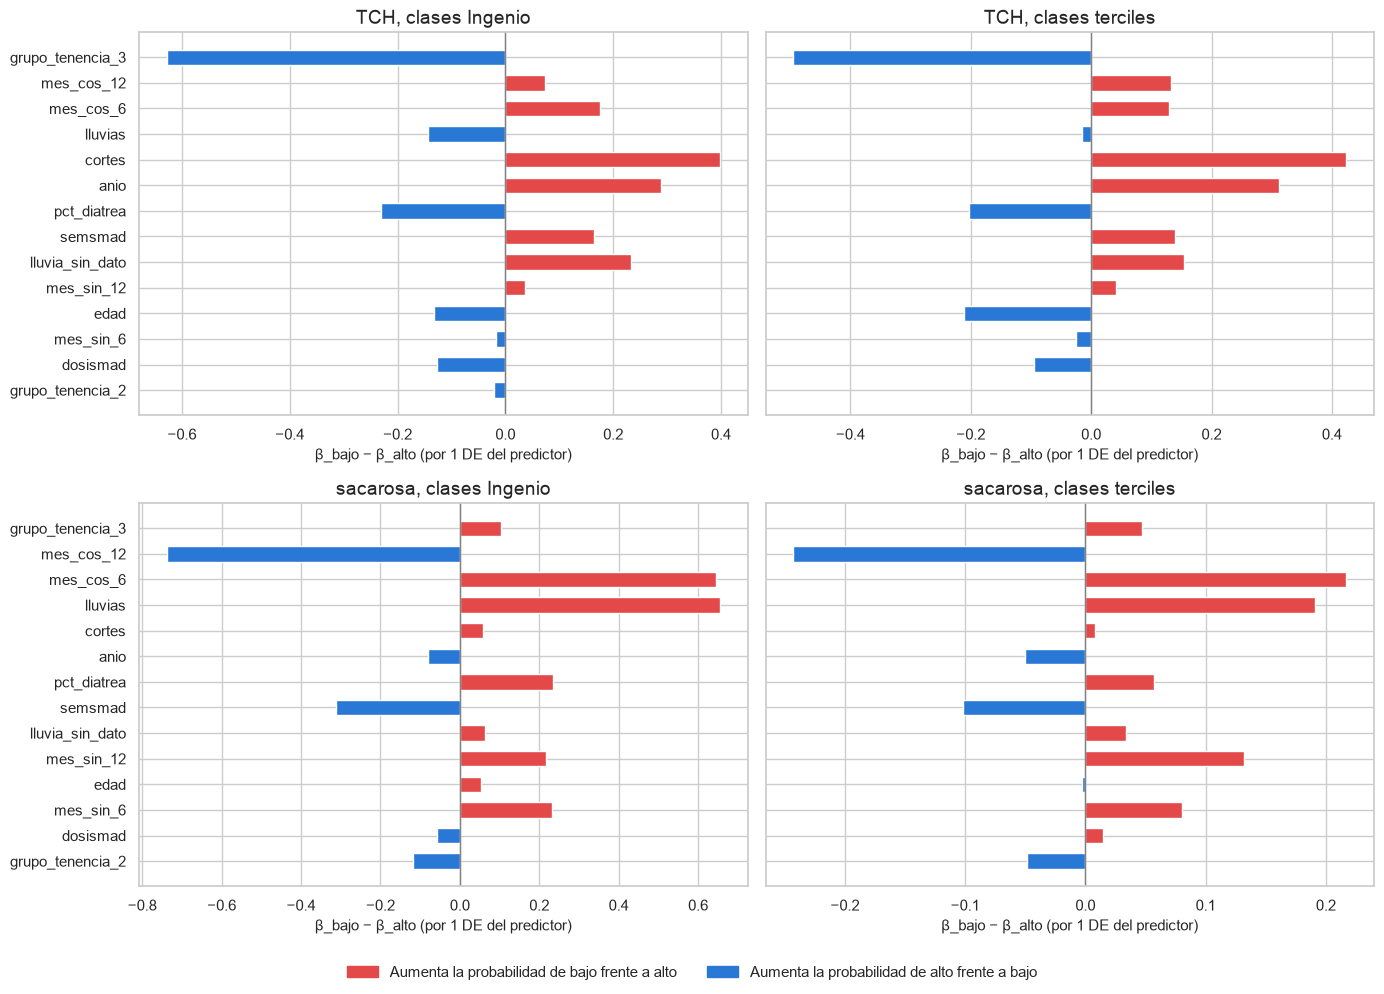

In [99]:
# 14.3 Contraste β_bajo − β_alto de cada predictor, por caso
COLOR_BAJO, COLOR_ALTO = "#e34948", "#2a78d6"  # hacia la clase baja / hacia la clase alta

# Mismo orden de predictores en los cuatro paneles: de mayor a menor contraste absoluto promedio
orden = (pd.DataFrame({caso: t["β_bajo − β_alto"] for caso, t in tablas_coef.items()})
         .abs().mean(axis=1).sort_values().index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for ax, ((tgt, defin), tabla) in zip(axes.ravel(), tablas_coef.items()):
    valores = tabla.loc[orden, "β_bajo − β_alto"]
    colores = np.where(valores > 0, COLOR_BAJO, COLOR_ALTO)
    ax.barh(orden, valores, color=colores, height=0.6)
    for pos, nombre in enumerate(orden):
        if tabla.loc[nombre, "Eliminada por L1"]:
            ax.text(0, pos, "  eliminada", va="center", fontsize=9, color="gray")
    ax.axvline(0, color="gray", linewidth=1)
    ax.set(title=f"{tgt}, clases {defin}", xlabel="β_bajo − β_alto (por 1 DE del predictor)")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=COLOR_BAJO),
                    plt.Rectangle((0, 0), 1, 1, color=COLOR_ALTO)],
           labels=["Aumenta la probabilidad de bajo frente a alto",
                   "Aumenta la probabilidad de alto frente a bajo"],
           loc="lower center", ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

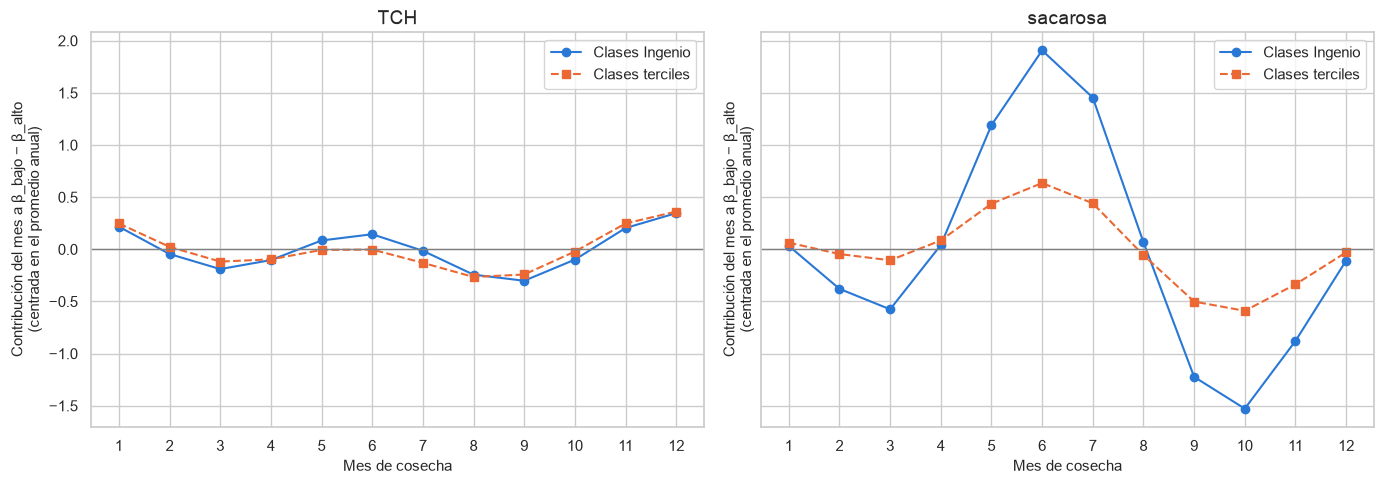

In [100]:
# 14.3 Efecto conjunto del mes de cosecha sobre el contraste bajo frente a alto
meses = np.arange(1, 13)
armonicos = pd.DataFrame({
    "mes_sin_12": np.sin(2 * np.pi * meses / 12), "mes_cos_12": np.cos(2 * np.pi * meses / 12),
    "mes_sin_6": np.sin(4 * np.pi * meses / 12), "mes_cos_6": np.cos(4 * np.pi * meses / 12),
}, index=meses)
estilos = {"Ingenio": ("#2a78d6", "o", "-"), "terciles": ("#eb6834", "s", "--")}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, tgt in zip(axes, ["TCH", "sacarosa"]):
    for defin, (color, marcador, linea) in estilos.items():
        final = busquedas_log[(tgt, defin)].best_estimator_
        escalado = final.named_steps["prep"].named_steps["escalado"]
        nombres = list(final.named_steps["prep"].get_feature_names_out())
        idx = [nombres.index(c) for c in predictores_mes]
        # Armónicos estandarizados con la media y la desviación de entrenamiento
        z = (armonicos[predictores_mes] - escalado.mean_[idx]) / escalado.scale_[idx]
        efecto = z @ contraste_bajo_alto(final)[predictores_mes].to_numpy()
        ax.plot(meses, efecto - efecto.mean(), linea, marker=marcador, color=color,
                label=f"Clases {defin}")
    ax.axhline(0, color="gray", linewidth=1)
    ax.set(title=tgt, xlabel="Mes de cosecha", xticks=meses,
           ylabel="Contribución del mes a β_bajo − β_alto\n(centrada en el promedio anual)")
    ax.legend()
plt.tight_layout()
plt.show()

### Conclusión de 14.3

**Cómo leer las tablas**

Cada tabla compara la clase baja con la alta. El contraste $\beta_{\text{bajo}} - \beta_{\text{alto}}$
indica hacia qué clase empuja cada predictor: si es positivo, valores más altos del predictor hacen más
probable la clase baja; si es negativo, la alta. La razón de odds es la exponencial del contraste, y dice
por cuánto se multiplica la razón entre la probabilidad de bajo y la de alto cuando el predictor aumenta
en la cantidad indicada en la columna "Aumento de referencia". Esa cantidad es una desviación estándar
del predictor en el conjunto de entrenamiento, expresada en sus unidades originales.

Por ejemplo, `cortes` en TCH tiene una razón de odds de 1.54 con un aumento de referencia de 1.6 cortes:
si dos cosechas son iguales en todo, salvo que una tiene 1.6 cortes más, la razón entre su probabilidad
de TCH bajo y su probabilidad de TCH alto es 1.54 veces la de la otra. Una razón de odds de 1 indica que
el predictor no distingue la clase baja de la alta. Por debajo de 1, el predictor empuja hacia la clase
alta. Como todos los contrastes están en la misma escala, su magnitud permite comparar la importancia de
predictores medidos en unidades distintas.

En las indicadoras (`grupo_tenencia`) el aumento de referencia no tiene una lectura natural, porque la
variable solo vale 0 o 1. En ellas se interpretan el signo y la magnitud relativa. Los armónicos del mes
se interpretan juntos, con la curva de la contribución de cada mes.

**Selección de variables y estabilidad**

- La regularización L1 casi no eliminó columnas: ninguna en TCH ni en sacarosa con umbrales del
  Ingenio, y tres en sacarosa por terciles (`anio`, `dosismad` y `grupo_tenencia_3`). Con los valores de
  `C` elegidos (0.1 y 0.316) la penalización es moderada, así que la importancia de cada predictor se lee
  en la magnitud de su contraste y en su estabilidad entre pliegues, más que en su eliminación.
- En la regresión logística multinomial, L1 penaliza por separado el coeficiente de cada clase. Por eso
  una columna puede tener contraste nulo entre bajo y alto sin estar eliminada, como `lluvias` en TCH con
  umbrales del Ingenio: conserva un coeficiente en alguna clase, pero no distingue la clase baja de la
  alta.
- Los predictores con mayor contraste mantienen su signo en los 5 pliegues en los cuatro casos. Los que
  aparecen en menos de 5 pliegues o cambian de signo, en al menos una de las dos definiciones de clase,
  tienen contrastes por debajo de 0.07 en valor absoluto. En TCH son `lluvias` (solo con umbrales del
  Ingenio), `lluvia_sin_dato`, `grupo_tenencia_2`, `mes_cos_12` y `mes_cos_6`. En sacarosa son `cortes`,
  `edad`, `anio`, `dosismad` y `grupo_tenencia_3`. Su efecto no es interpretable.
- Las dos definiciones de clase identifican los mismos predictores principales en cada target, con los
  mismos signos y un orden de importancia similar. Las conclusiones sobre los predictores no dependen de
  cómo se definan las clases.

**TCH**

| Predictor | Razón de odds (Ingenio / terciles) | Aumento de referencia | Lectura |
|---|---|---|---|
| `cortes` | 1.54 / 1.51 | 1.6 cortes | Más cortes, más probable el TCH bajo |
| `anio` | 1.40 / 1.46 | 1.3 años | Cosechas más recientes, más probable el TCH bajo |
| `semsmad` | 1.17 / 1.20 | 3.4 semanas | Más semanas desde el madurante, más probable el TCH bajo |
| `edad` | 0.87 / 0.77 | 1.1 meses | Mayor edad, más probable el TCH alto |
| `pct_diatrea` | 0.83 / 0.86 | 2.6 puntos % | Más daño por *Diatraea*, más probable el TCH alto |
| `dosismad` | 0.86 / 0.89 | 0.25 L/ha | Mayor dosis de madurante, más probable el TCH alto |
| `grupo_tenencia_3` | 0.62 / 0.67 | Indicadora | El código 3 hace más probable el TCH alto que el código 1 |

Predictores con una explicación agronómica coherente:

- **`cortes`** tiene el mayor efecto hacia la clase baja: cada 1.6 cortes adicionales multiplican por
  cerca de 1.5 la razón entre la probabilidad de TCH bajo y la de alto. Es coherente con la pérdida de
  productividad de la cepa a medida que acumula cortes.
- **`edad`** empuja hacia la clase alta: una cosecha más tardía tuvo más tiempo para acumular biomasa.
- **`semsmad`** empuja hacia la clase baja. El madurante frena el crecimiento vegetativo para que la
  planta acumule sacarosa, así que una exposición más larga puede reducir el tonelaje.

Predictores sin una explicación agronómica directa:

- **`anio`** empuja hacia la clase baja: las cosechas más recientes del periodo 2014 a 2021 tienen mayor
  probabilidad de TCH bajo. Es una tendencia en el tiempo cuya causa no está en los datos, y su uso
  para cosechas futuras se evalúa en la sección 16.
- **`grupo_tenencia_3`** empuja hacia la clase alta frente al código 1, pero el significado de los
  códigos no está documentado, así que el efecto no se puede atribuir a una forma de tenencia. En el EDA,
  el código 3 mostró una dosis mediana de madurante menor, lo que sugiere un manejo distinto.
- **`pct_diatrea`** empuja hacia la clase alta, cuando se esperaría que más daño por *Diatraea* redujera
  el tonelaje. Como se mide en la cosecha, podría reflejar condiciones del cultivo asociadas a mayor
  biomasa, pero con estos datos no se puede verificar.
- **`dosismad`** empuja hacia la clase alta con un efecto pequeño. Se esperaría lo contrario si el
  madurante reduce el tonelaje, igual que con `semsmad`. La dosis varía poco en este dataset (0.25 L/ha
  en una desviación estándar), así que su efecto se estima con poca información.

Predictores sin efecto:

- **`lluvias`** y el mes de cosecha casi no distinguen la clase baja de la alta en TCH: la contribución
  del mes al contraste varía menos de 0.4 a lo largo del año.

**Sacarosa**

| Predictor | Razón de odds (Ingenio / terciles) | Aumento de referencia | Lectura |
|---|---|---|---|
| `lluvias` | 2.01 / 1.97 | 117 mm | Más lluvia, más probable la sacarosa baja |
| `pct_diatrea` | 1.28 / 1.19 | 2.6 puntos % | Más daño por *Diatraea*, más probable la sacarosa baja |
| `semsmad` | 0.66 / 0.65 | 3.4 semanas | Más semanas desde el madurante, más probable la sacarosa alta |
| `grupo_tenencia_2` | 0.90 / 0.87 | Indicadora | El código 2 hace algo más probable la sacarosa alta que el código 1 |
| Mes de cosecha | Ver gráfica | — | Mayo a julio, más probable la sacarosa baja; septiembre y octubre, la alta |

Predictores con una explicación agronómica coherente:

- **`lluvias`** es el predictor continuo más importante: cada 117 mm adicionales duplican la razón entre
  la probabilidad de sacarosa baja y la de alta. Es coherente con el efecto de la lluvia sobre la
  maduración: el agua estimula el crecimiento y diluye la sacarosa acumulada.
- **`semsmad`** empuja hacia la clase alta: más semanas entre la aplicación del madurante y la cosecha
  dan más tiempo para que el madurante actúe.
- **`pct_diatrea`** empuja hacia la clase baja: el daño por *Diatraea* se asocia con menor sacarosa, lo
  que es coherente con el deterioro de los tallos perforados.

El mes de cosecha:

- Tiene el efecto más fuerte de todos los predictores. Su contribución al contraste va de −1.4 en
  octubre a 2.0 en junio: las cosechas de mayo a julio tienden a la clase baja, y las de septiembre y
  octubre, y en menor medida las de febrero y marzo, a la alta.
- Este efecto se suma al de `lluvias`, así que no se explica solo por la lluvia registrada. Podría
  reflejar las condiciones de las semanas previas a la cosecha, en las que se completa la maduración.

Predictores sin efecto:

- `edad`, `anio`, `cortes` y `dosismad` tienen contrastes cercanos a cero, y `anio` y `dosismad` quedan
  eliminadas por L1 con terciles. La sacarosa no muestra tendencia entre años. La dosis de madurante no
  distingue la clase baja de la alta, aunque en este dataset todas las suertes fueron maduradas y la
  dosis varía poco, así que el rango observado puede ser demasiado estrecho para que su efecto se
  manifieste.

**TCH frente a sacarosa**

- Los predictores más importantes son distintos para cada target. TCH depende sobre todo del estado de
  la cepa y del cultivo (`cortes`, `edad`, `grupo_tenencia`), y la sacarosa de las condiciones de
  maduración (`lluvias`, mes de cosecha, `semsmad`). Esto confirma que conviene tratarlos como dos
  problemas independientes.
- `semsmad` tiene signos opuestos en los dos targets: más tiempo de acción del madurante favorece la
  sacarosa y se asocia con menor tonelaje.

### Conclusión de la sección 14

- La regresión logística multinomial supera a los clasificadores de referencia en los cuatro casos, con
  un F1 macro de 0.433 a 0.493 frente a un máximo de 0.342 sin predictores, y un kappa de 0.175 a 0.271
  frente a prácticamente 0. El acuerdo es leve a aceptable: los predictores disponibles antes de la
  cosecha distinguen las clases, pero explican una parte limitada del resultado.
- La sacarosa se clasifica mejor que TCH, sobre todo en la identificación de la clase baja (AUC de 0.76
  frente a 0.65). En sacarosa con umbrales del Ingenio, el modelo ordena bien las cosechas según su
  riesgo de ser bajas, pero con la regla de la clase más probable detecta solo el 28.1 % de ellas.
- El desempeño es estable en un rango amplio de regularización (C desde 0.1 hasta 100), y L1 y L2 son
  equivalentes en desempeño. Se usa L1 por su interpretación, aunque con la penalización elegida casi no
  elimina predictores.
- Los predictores principales son distintos para cada target: `cortes`, `edad`, `anio` y
  `grupo_tenencia` en TCH, y `lluvias`, el mes de cosecha y `semsmad` en sacarosa. Son los mismos con las
  dos definiciones de clase, y la mayoría tiene una explicación agronómica coherente. Las excepciones
  (`pct_diatrea` y `dosismad` en TCH, y la tendencia de `anio`) quedan identificadas como efectos sin una
  explicación directa.
- Los modelos elegidos en esta sección se evalúan en el conjunto de prueba en la sección 17, junto con
  los de KNN.

## 15. KNN

KNN (k vecinos más cercanos) clasifica cada cosecha según las clases de las k cosechas de entrenamiento
más parecidas. Estima la probabilidad de cada clase como la proporción de vecinos que pertenecen a ella:

$$\hat P(\text{clase } c \mid x) = \frac{\sum_{i \in N_k(x)} w_i \, \mathbb{1}(y_i = c)}{\sum_{i \in N_k(x)} w_i}$$

donde $N_k(x)$ son los k vecinos más cercanos a $x$ según la distancia euclidiana sobre los predictores
estandarizados, y $w_i$ es el peso de cada vecino: igual para todos (ponderación uniforme) o inversamente
proporcional a su distancia (ponderación por distancia).

KNN complementa a la regresión logística en tres aspectos:

- **Fronteras no lineales.** No supone que el efecto de cada predictor sea lineal ni aditivo, así que
  puede capturar interacciones, por ejemplo entre lluvias y mes de cosecha.
- **Sin coeficientes.** No produce una medida directa de la importancia de cada predictor.
- **Todos los predictores pesan igual en la distancia.** La logística aprende un peso para cada
  predictor, mientras que KNN da el mismo peso a todas las columnas estandarizadas, incluidas las que
  aportan poca información. Por eso es sensible a la selección de predictores, lo que se evalúa en la
  sección 16.

KNN no tiene un equivalente a la ponderación de clases de la logística, así que la clase baja, que es la
más pequeña con los umbrales del Ingenio, no recibe un peso adicional.

La sección tiene tres partes: la búsqueda de hiperparámetros (15.1), un diagnóstico de la similitud
entre cada cosecha y sus vecinos más cercanos (15.2) y la comparación con la regresión logística (15.3).

### 15.1 Búsqueda de hiperparámetros

Se buscan dos hiperparámetros con la misma validación cruzada, las mismas métricas y el mismo criterio
de elección que en la regresión logística (mayor F1 macro):

- **`n_neighbors` (k):** valores impares de 1 a 51, para evitar empates entre clases con ponderación
  uniforme. Un k pequeño produce fronteras muy irregulares que se ajustan al ruido de los datos de
  entrenamiento; un k grande las suaviza, pero puede borrar diferencias reales entre clases.
- **`weights`:** ponderación uniforme o por distancia.

La gráfica muestra el F1 macro de validación cruzada frente a k para cada ponderación, con una banda de
± una desviación estándar entre pliegues. Si el k elegido queda en el extremo de la grilla, el rango
explorado sería insuficiente.

In [101]:
# 15.1 Búsqueda de hiperparámetros de KNN
from sklearn.neighbors import KNeighborsClassifier

grilla_knn = {
    "modelo__n_neighbors": list(range(1, 52, 2)),  # k impar de 1 a 51
    "modelo__weights": ["uniform", "distance"],
}

busquedas_knn = {caso: buscar(KNeighborsClassifier(), grilla_knn, col) for caso, col in casos.items()}

tabla_knn = pd.DataFrame({caso: resumen_busqueda(b) for caso, b in busquedas_knn.items()}).T
tabla_knn.index.names = ["Target", "Clases"]
display(tabla_knn)

n_neighbors   weights      exactitud     prec_macro  \
Target   Clases                                                         
TCH      Ingenio           13  distance  0.528 ± 0.026  0.529 ± 0.025   
         terciles          51  distance  0.514 ± 0.010  0.503 ± 0.009   
sacarosa Ingenio           13  distance  0.573 ± 0.023  0.558 ± 0.025   
         terciles          13  distance  0.542 ± 0.012  0.532 ± 0.016   

                      sens_macro       f1_macro      prec_bajo      sens_bajo  \
Target   Clases                                                                 
TCH      Ingenio   0.501 ± 0.027  0.507 ± 0.027  0.526 ± 0.038  0.334 ± 0.042   
         terciles  0.510 ± 0.010  0.501 ± 0.008  0.535 ± 0.031  0.586 ± 0.019   
sacarosa Ingenio   0.548 ± 0.026  0.550 ± 0.026  0.534 ± 0.033  0.441 ± 0.054   
         terciles  0.540 ± 0.012  0.533 ± 0.014  0.580 ± 0.028  0.627 ± 0.020   

                           kappa      auc_macro       auc_bajo  
Target   Clases                                                 
TCH      Ingenio   0.258 ± 0.042  0.684 ± 0.023  0.707 ± 0.037  
         terciles  0.268 ± 0.016  0.666 ± 0.009  0.696 ± 0.016  
sacarosa Ingenio   0.329 ± 0.038  0.724 ± 0.020  0.764 ± 0.035  
         terciles  0.312 ± 0.017  0.712 ± 0.009  0.761 ± 0.012

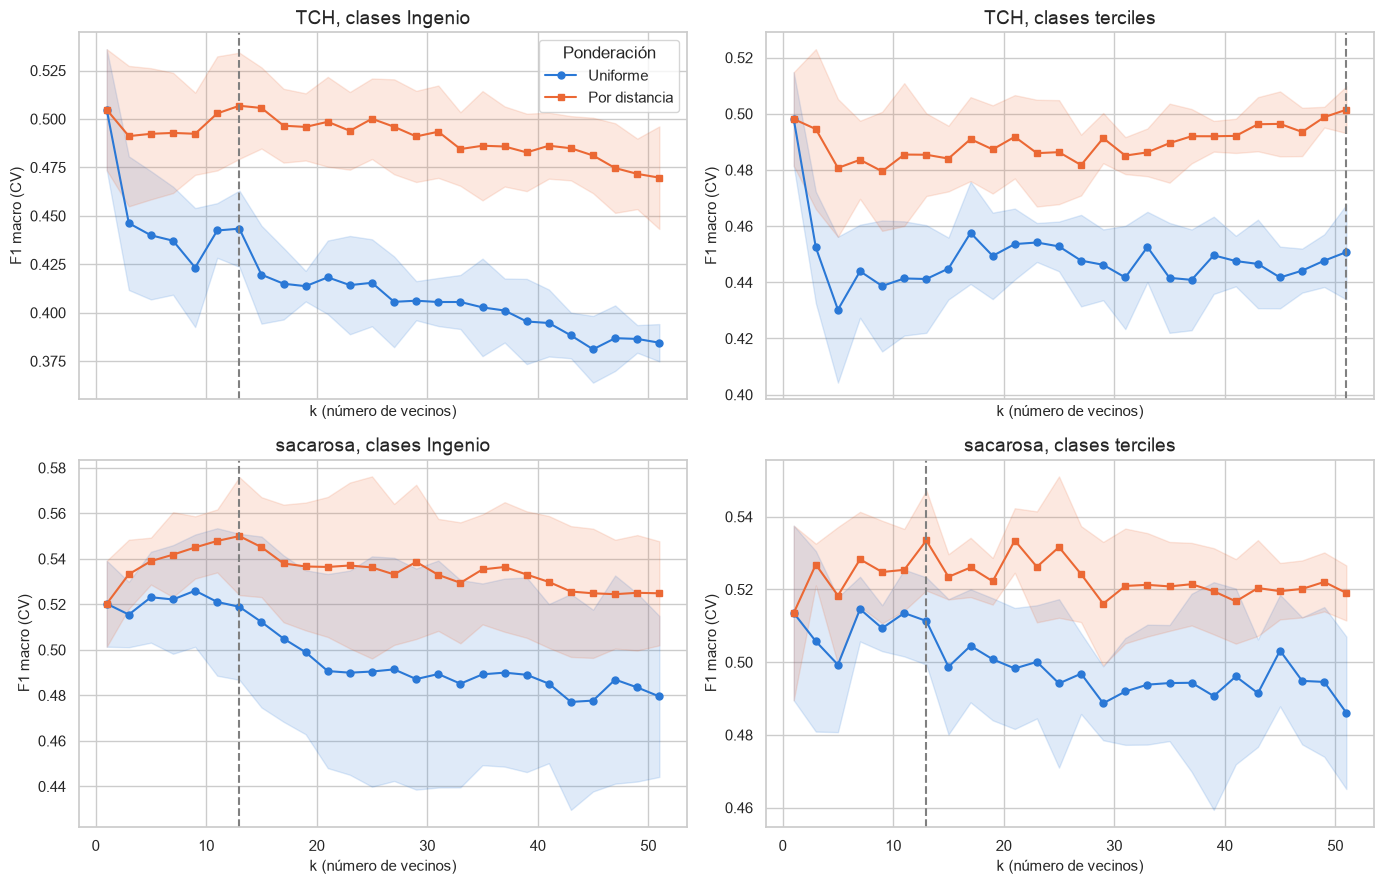

In [102]:
# 15.1 F1 macro de validación cruzada frente a k, por tipo de ponderación
estilos_knn = {"uniform": ("#2a78d6", "o", "Uniforme"), "distance": ("#eb6834", "s", "Por distancia")}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (caso, busqueda) in zip(axes.ravel(), busquedas_knn.items()):
    res = pd.DataFrame(busqueda.cv_results_)
    for peso, (color, marcador, etiqueta) in estilos_knn.items():
        grupo = res[res["param_modelo__weights"] == peso]
        k = grupo["param_modelo__n_neighbors"].astype(int)
        media, desv = grupo["mean_test_f1_macro"], grupo["std_test_f1_macro"]
        ax.plot(k, media, marker=marcador, color=color, label=etiqueta, markersize=5)
        ax.fill_between(k, media - desv, media + desv, color=color, alpha=0.15)
    k_elegido = busqueda.cv_results_["param_modelo__n_neighbors"][busqueda.best_index_]
    ax.axvline(int(k_elegido), color="gray", linestyle="--")
    ax.set(title=f"{caso[0]}, clases {caso[1]}", xlabel="k (número de vecinos)", ylabel="F1 macro (CV)")
axes[0, 0].legend(title="Ponderación")
plt.tight_layout()
plt.show()

### Conclusión de 15.1

| Target | Clases | k | Ponderación | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | 3 | Por distancia | 0.487 ± 0.031 | 0.449 ± 0.054 | 0.378 ± 0.067 | 0.229 ± 0.043 | 0.643 ± 0.022 | 0.649 ± 0.023 |
| TCH | Terciles | 1 | Uniforme | 0.468 ± 0.021 | 0.526 ± 0.024 | 0.506 ± 0.043 | 0.206 ± 0.033 | 0.602 ± 0.016 | 0.632 ± 0.014 |
| Sacarosa | Ingenio | 11 | Por distancia | 0.534 ± 0.025 | 0.507 ± 0.066 | 0.408 ± 0.052 | 0.309 ± 0.041 | 0.715 ± 0.025 | 0.759 ± 0.017 |
| Sacarosa | Terciles | 9 | Por distancia | 0.523 ± 0.014 | 0.593 ± 0.017 | 0.598 ± 0.029 | 0.291 ± 0.019 | 0.709 ± 0.012 | 0.768 ± 0.014 |

- KNN supera a los clasificadores de referencia en los cuatro casos, con un F1 macro de 0.468 a 0.534
  frente a un máximo de 0.342, y un kappa de 0.206 a 0.309.
- La ponderación por distancia obtiene un F1 macro igual o mayor que la uniforme para casi todos los
  valores de k. En TCH la diferencia es de 0.04 a 0.08 en la mayor parte del rango. Con k = 1, elegido en
  TCH por terciles, las dos ponderaciones son equivalentes.
- En TCH el mejor desempeño se obtiene con el menor número de vecinos (k = 3 con umbrales del Ingenio y
  k = 1 con terciles), y el F1 macro disminuye a medida que k aumenta. La clase de una cosecha se predice
  mejor a partir de la cosecha de entrenamiento más parecida que a partir de un grupo de vecinos. En
  sacarosa el F1 macro alcanza su máximo con k entre 9 y 13 y disminuye para valores mayores.
- Ningún k elegido queda en el extremo superior de la grilla, así que el rango explorado es suficiente.
- Con k = 1, cada cosecha recibe la clase de un único vecino y su probabilidad estimada es 0 o 1. Por
  eso, en TCH por terciles el AUC (0.602 macro y 0.632 de la clase baja) es bajo en relación con su F1
  macro: el modelo no ordena las cosechas según su riesgo, solo les asigna una clase.
- Que el vecino más cercano sea el más informativo en TCH sugiere que existen cosechas de entrenamiento
  muy parecidas a las de validación en sus predictores y en su resultado. Antes de comparar KNN con la
  regresión logística, en 15.2 se analiza de dónde proviene esa similitud.

### 15.2 Diagnóstico de los vecinos más cercanos

En TCH, KNN obtuvo su mejor desempeño con uno o tres vecinos. Una posible explicación es la estructura
de los datos: la partición agrupa por suerte, pero varias suertes de una misma hacienda suelen
cosecharse en el mismo periodo. Esas suertes comparten el año, el mes, la lluvia registrada y el grupo de
tenencia, y pueden tener valores parecidos de los demás predictores y resultados parecidos, por
compartir suelo, manejo y condiciones climáticas. Si es así, el vecino más cercano de una cosecha de
validación sería con frecuencia otra suerte de la misma hacienda cosechada al mismo tiempo, y KNN
tomaría su clase.

Ese desempeño no se reproduciría en la práctica. Al clasificar una cosecha antes de que ocurra, las
suertes de la misma hacienda que se cosechan en el mismo periodo tampoco tienen todavía su resultado,
así que no pueden servir como vecinos.

Para evaluar esta explicación, se busca el vecino más cercano de cada cosecha de entrenamiento entre las
cosechas de otras suertes, como ocurre en la validación cruzada, sobre la matriz de diseño estandarizada
de 13.2. Los vecinos se clasifican según si pertenecen a la misma hacienda y al mismo periodo de cosecha
(`periodo`, año y mes). Para cada grupo se calculan la distancia mediana al vecino y el porcentaje de
cosechas que tienen la misma clase que su vecino, que se compara con la coincidencia esperada por azar:
la probabilidad de que dos cosechas tomadas al azar pertenezcan a la misma clase.

In [103]:
# 15.2 Vecino más cercano de cada cosecha de entrenamiento, excluyendo su propia suerte
from sklearn.metrics import pairwise_distances

# Distancias euclidianas sobre la matriz de diseño estandarizada de 13.2
distancias = pairwise_distances(X_train_prep)
suertes = df_train["suerte"].to_numpy()
distancias[suertes[:, None] == suertes[None, :]] = np.inf  # la validación nunca incluye la misma suerte

idx_vecino = distancias.argmin(axis=1)
vecino = df_train.iloc[idx_vecino].reset_index(drop=True)
propio = df_train.reset_index(drop=True)

misma_hacienda = (propio["FAZ"] == vecino["FAZ"]).to_numpy()
mismo_periodo = (propio["periodo"] == vecino["periodo"]).to_numpy()
relacion = pd.Series(np.select(
    [misma_hacienda & mismo_periodo, misma_hacienda, mismo_periodo],
    ["Misma hacienda y mismo periodo", "Misma hacienda, otro periodo", "Otra hacienda, mismo periodo"],
    default="Otra hacienda y otro periodo",
), name="Relación con el vecino más cercano")


def coincide(col):
    """1 si la cosecha y su vecino tienen la misma clase, 0 si no, NaN si alguna no tiene clase."""
    a, b = propio[col].astype(object), vecino[col].astype(object)
    return (a == b).astype(float).where(a.notna() & b.notna())


diagnostico = pd.DataFrame({
    "Registros": relacion.value_counts(),
    "% de registros": relacion.value_counts(normalize=True).mul(100).round(1),
    "Distancia mediana": pd.Series(distancias.min(axis=1)).groupby(relacion).median().round(2),
    "% misma clase TCH (Ingenio)": coincide("clase_tch_ingenio").groupby(relacion).mean().mul(100).round(1),
    "% misma clase sacarosa (Ingenio)": coincide("clase_sac_ingenio").groupby(relacion).mean().mul(100).round(1),
}).reindex(["Misma hacienda y mismo periodo", "Misma hacienda, otro periodo",
            "Otra hacienda, mismo periodo", "Otra hacienda y otro periodo"])
display(diagnostico)

# Coincidencia esperada por azar: probabilidad de que dos cosechas al azar tengan la misma clase
azar = {col: (df_train[col].value_counts(normalize=True) ** 2).sum() * 100
        for col in ["clase_tch_ingenio", "clase_sac_ingenio"]}
print(f"Coincidencia esperada por azar: TCH {azar['clase_tch_ingenio']:.1f} % | "
      f"sacarosa {azar['clase_sac_ingenio']:.1f} %")

,Registros,% de registros,Distancia mediana,% misma clase TCH (Ingenio),% misma clase sacarosa (Ingenio)
Relación con el vecino más cercano,,,,,
Misma hacienda y mismo periodo,787,45.3,0.26,65.0,56.4
"Misma hacienda, otro periodo",18,1.0,1.81,61.1,33.3
"Otra hacienda, mismo periodo",722,41.6,0.98,43.0,54.4
Otra hacienda y otro periodo,210,12.1,1.80,38.6,40.5


Coincidencia esperada por azar: TCH 35.1 % | sacarosa 35.6 %


Para medir el efecto de esta similitud en el desempeño, se repite la validación cruzada con los pliegues
agrupados de tres formas:

- **Por suerte**, como hasta ahora: al validar una cosecha, las demás suertes de su hacienda y de su
  periodo pueden estar en entrenamiento.
- **Por hacienda:** todas las cosechas de una hacienda quedan en el mismo pliegue, así que el modelo se
  evalúa en haciendas que no vio.
- **Por periodo de cosecha:** todas las cosechas de un mismo mes y año quedan en el mismo pliegue, así
  que el modelo no dispone de ninguna cosecha simultánea. Es la situación más cercana al uso del modelo
  para clasificar las cosechas de un periodo antes de que ocurran.

Con cada agrupación se vuelve a buscar el hiperparámetro principal de cada modelo (`C` en la regresión
logística y k en KNN), porque su valor óptimo puede depender de la agrupación. El tipo de regularización,
la ponderación de clases de la logística y la ponderación de los vecinos se mantienen como se eligieron
en 14.2 y 15.1. Si el desempeño de KNN cae al agrupar por hacienda o por periodo, su ventaja con la
agrupación por suerte proviene de las cosechas simultáneas.

In [104]:
# 15.2 Desempeño en validación cruzada según la variable con que se agrupan los pliegues
agrupaciones = {"Suerte": "suerte", "Hacienda": "FAZ", "Periodo": "periodo"}


def cv_agrupada(modelo, grilla, col_clase, col_grupo):
    """Búsqueda con pliegues agrupados por col_grupo. Devuelve F1 macro, kappa y el k o C elegido."""
    d = df_train[df_train[col_clase].notna()]
    busqueda = GridSearchCV(
        Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]),
        grilla, scoring={"f1_macro": "f1_macro", "kappa": metricas["kappa"]}, refit="f1_macro",
        cv=cv, n_jobs=-1,
    ).fit(d[columnas_entrada], d[col_clase].astype(str), groups=d[col_grupo])
    fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
    return {"F1 macro": fila["mean_test_f1_macro"], "Kappa": fila["mean_test_kappa"],
            "Hiperparámetro": next(iter(busqueda.best_params_.values()))}


filas = []
for caso, col in casos.items():
    for nombre_grupo, col_grupo in agrupaciones.items():
        # Logística con la regularización y la ponderación elegidas en 14.2; solo se vuelve a buscar C
        params_log = busquedas_log[caso].best_params_
        log = cv_agrupada(
            LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE,
                               l1_ratio=params_log["modelo__l1_ratio"],
                               class_weight=params_log["modelo__class_weight"]),
            {"modelo__C": grilla_log["modelo__C"]}, col, col_grupo)
        # KNN con la ponderación elegida en 15.1; se vuelve a buscar k
        params_knn = busquedas_knn[caso].best_params_
        knn = cv_agrupada(KNeighborsClassifier(weights=params_knn["modelo__weights"]),
                          {"modelo__n_neighbors": grilla_knn["modelo__n_neighbors"]}, col, col_grupo)
        filas.append({"Target": caso[0], "Clases": caso[1], "Pliegues agrupados por": nombre_grupo,
                      "F1 logística": log["F1 macro"], "C logística": log["Hiperparámetro"],
                      "F1 KNN": knn["F1 macro"], "k KNN": knn["Hiperparámetro"],
                      "Kappa logística": log["Kappa"], "Kappa KNN": knn["Kappa"]})

tabla_agrupacion = pd.DataFrame(filas).set_index(["Target", "Clases", "Pliegues agrupados por"])
display(tabla_agrupacion.round(3))

F1 logística  C logística  F1 KNN  \
Target   Clases   Pliegues agrupados por                                      
TCH      Ingenio  Suerte                         0.439        1.000   0.507   
                  Hacienda                       0.416        3.162   0.390   
                  Periodo                        0.417       31.623   0.382   
         terciles Suerte                         0.479        0.316   0.501   
                  Hacienda                       0.453       10.000   0.436   
                  Periodo                        0.450        1.000   0.450   
sacarosa Ingenio  Suerte                         0.486        0.316   0.550   
                  Hacienda                       0.474        0.316   0.503   
                  Periodo                        0.422       10.000   0.434   
         terciles Suerte                         0.497        0.001   0.533   
                  Hacienda                       0.493        0.001   0.504   
                  Periodo                        0.437        0.001   0.464   

                                          k KNN  Kappa logística  Kappa KNN  
Target   Clases   Pliegues agrupados por                                     
TCH      Ingenio  Suerte                     13            0.180      0.258  
                  Hacienda                    1            0.150      0.090  
                  Periodo                    31            0.146      0.112  
         terciles Suerte                     51            0.227      0.268  
                  Hacienda                   31            0.193      0.165  
                  Periodo                    25            0.188      0.183  
sacarosa Ingenio  Suerte                     13            0.256      0.329  
                  Hacienda                   13            0.240      0.263  
                  Periodo                    33            0.179      0.184  
         terciles Suerte                     13            0.268      0.312  
                  Hacienda                   25            0.266      0.274  
                  Periodo                    39            0.210      0.223